ETAPA 1 - TRATAMENTO DADOS - CARPRICE.CSV


In [297]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats
from statsmodels.stats.diagnostic import het_breuschpagan, linear_reset
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from sklearn.model_selection import train_test_split, RepeatedKFold, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import sweetviz as sv
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant


In [298]:
df = pd.read_csv('CarPrice_Assignment.csv')

In [299]:
df.shape

(205, 26)

In [300]:
# Dicionário para mapear nomes de colunas de inglês para português
column_translations = {
    'car_ID': 'ID_carro',
    'symboling': 'simbolizacao_risco',
    'CarName': 'nome_carro',
    'fueltype': 'tipo_combustivel',
    'aspiration': 'aspiracao',
    'doornumber': 'numero_portas',
    'carbody': 'tipo_carroceria',
    'drivewheel': 'tipo_tracao',
    'enginelocation': 'localizacao_motor',
    'wheelbase': 'distancia_entre_eixos',
    'carlength': 'comprimento_carro',
    'carwidth': 'largura_carro',
    'carheight': 'altura_carro',
    'curbweight': 'peso_em_ordem_de_marcha',
    'enginetype': 'tipo_motor',
    'cylindernumber': 'numero_cilindros',
    'enginesize': 'tamanho_motor',
    'fuelsystem': 'sistema_combustivel',
    'boreratio': 'diametro_cilindro',
    'stroke': 'curso_pistao',
    'compressionratio': 'taxa_compressao',
    'horsepower': 'potencia_hp',
    'peakrpm': 'rpm_maximo',
    'citympg': 'consumo_cidade_mpg',
    'highwaympg': 'consumo_estrada_mpg',
    'price': 'preco'
}

# Renomear as colunas do DataFrame
df.rename(columns=column_translations, inplace=True)

print("Colunas do DataFrame traduzidas com sucesso!")

# Exibir as primeiras 5 linhas do DataFrame com as novas colunas
display(df.head())

Colunas do DataFrame traduzidas com sucesso!


,ID_carro,simbolizacao_risco,nome_carro,tipo_combustivel,aspiracao,numero_portas,tipo_carroceria,tipo_tracao,localizacao_motor,distancia_entre_eixos,comprimento_carro,largura_carro,altura_carro,peso_em_ordem_de_marcha,tipo_motor,numero_cilindros,tamanho_motor,sistema_combustivel,diametro_cilindro,curso_pistao,taxa_compressao,potencia_hp,rpm_maximo,consumo_cidade_mpg,consumo_estrada_mpg,preco
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [301]:
# Exibir os tipos de dados de cada coluna
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID_carro                 205 non-null    int64  
 1   simbolizacao_risco       205 non-null    int64  
 2   nome_carro               205 non-null    object 
 3   tipo_combustivel         205 non-null    object 
 4   aspiracao                205 non-null    object 
 5   numero_portas            205 non-null    object 
 6   tipo_carroceria          205 non-null    object 
 7   tipo_tracao              205 non-null    object 
 8   localizacao_motor        205 non-null    object 
 9   distancia_entre_eixos    205 non-null    float64
 10  comprimento_carro        205 non-null    float64
 11  largura_carro            205 non-null    float64
 12  altura_carro             205 non-null    float64
 13  peso_em_ordem_de_marcha  205 non-null    int64  
 14  tipo_motor               2

In [302]:
# Verificar valores ausentes por coluna
missing_values = df.isnull().sum()

print("Valores ausentes por coluna:")
display(missing_values[missing_values > 0]) # Exibe apenas as colunas com valores ausentes

if missing_values.sum() == 0:
    print("Não há valores ausentes no DataFrame.")

Valores ausentes por coluna:


Series([], dtype: int64)

Não há valores ausentes no DataFrame.


In [303]:
df["nome_carro"].value_counts().reset_index()

,nome_carro,count
0,toyota corona,6
1,toyota corolla,6
2,peugeot 504,6
3,subaru dl,4
4,mitsubishi mirage g4,3
...,...,...
142,mazda glc 4,1
143,mazda rx2 coupe,1
144,maxda glc deluxe,1
145,maxda rx3,1


In [304]:
#  Mapeamento para Correção de Erros de Digitação nas Marcas
brand_fixes = {
    'maxda': 'mazda',
    'porcshce': 'porsche',
    'porcshz': 'porsche',
    'toyouta': 'toyota',
    'vokswagen': 'volkswagen',
    'vw': 'volkswagen',
    'alfa-romero': 'alfa-romeo'
}

# 3. Limpeza do Nome do Carro
def limpar_nome_carro(nome):
    nome = str(nome).lower().strip()
    parts = nome.split(' ')
    marca = parts[0]
    marca = brand_fixes.get(marca, marca)
    resto = ' '.join(parts[1:])
    return f"{marca} {resto}".strip()

df['nome_carro'] = df['nome_carro'].apply(limpar_nome_carro)

#  Criação da Feature 'marca' (Engenharia de Recursos)
# Esta é a melhor abordagem para análise estatística, VIF e modelos de Machine Learning
df['marca'] = df['nome_carro'].apply(lambda x: x.split(' ')[0])


In [305]:
df.head(2)

,ID_carro,simbolizacao_risco,nome_carro,tipo_combustivel,aspiracao,numero_portas,tipo_carroceria,tipo_tracao,localizacao_motor,distancia_entre_eixos,comprimento_carro,largura_carro,altura_carro,peso_em_ordem_de_marcha,tipo_motor,numero_cilindros,tamanho_motor,sistema_combustivel,diametro_cilindro,curso_pistao,taxa_compressao,potencia_hp,rpm_maximo,consumo_cidade_mpg,consumo_estrada_mpg,preco,marca
0,1,3,alfa-romeo giulia,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romeo
1,2,3,alfa-romeo stelvio,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romeo


In [306]:
df['marca'].value_counts().reset_index()

,marca,count
0,toyota,32
1,nissan,18
2,mazda,17
3,mitsubishi,13
4,honda,13
5,volkswagen,12
6,subaru,12
7,peugeot,11
8,volvo,11
9,dodge,9


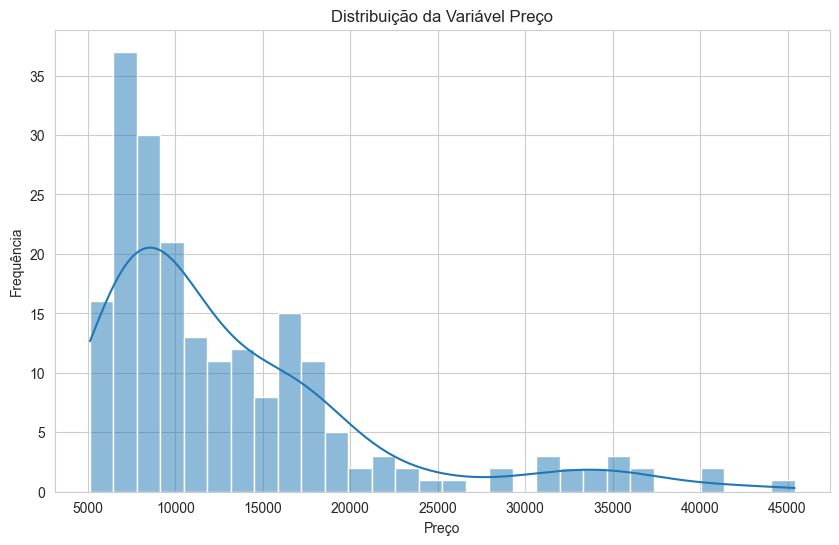

In [307]:
plt.figure(figsize=(10, 6))
sns.histplot(df['preco'], kde=True, bins=30)
plt.title('Distribuição da Variável Preço')
plt.xlabel('Preço')
plt.ylabel('Frequência')
plt.grid(True)
plt.show()

In [308]:
df['preco'].describe()

count      205.000000
mean     13276.710571
std       7988.852332
min       5118.000000
25%       7788.000000
50%      10295.000000
75%      16503.000000
max      45400.000000
Name: preco, dtype: float64

In [309]:
# Analisar o DataFrame
#analise_sweetviz = sv.analyze(df)

# Exibir o relatório no Colab ou salvá-lo como HTML
#analise_sweetviz.show_html('relatorio_eda_sweetviz.html')
print('Relatório de EDA com Sweetviz gerado: relatorio_eda_sweetviz.html')

Relatório de EDA com Sweetviz gerado: relatorio_eda_sweetviz.html


In [310]:
# Gerar um resumo estatístico do DataFrame
display(df.describe())

,ID_carro,simbolizacao_risco,distancia_entre_eixos,comprimento_carro,largura_carro,altura_carro,peso_em_ordem_de_marcha,tamanho_motor,diametro_cilindro,curso_pistao,taxa_compressao,potencia_hp,rpm_maximo,consumo_cidade_mpg,consumo_estrada_mpg,preco
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


Análise dos Boxplots -Variáveis Categóricas por Preço(Variável Quantitativa)

1. Distribuição do Preço por Tipo de Combustível (tipo_combustivel)
Observação: O boxplot mostra que veículos movidos a diesel tendem a ter um preço médio e mediana mais altos em comparação com veículos a gasolina (gas). A dispersão dos preços para carros a diesel também parece ser um pouco menor, sugerindo uma faixa de preço mais concentrada para este tipo de combustível, enquanto carros a gasolina apresentam uma distribuição de preços mais ampla e com alguns outliers de alto valor.
2. Distribuição do Preço por Aspiração (aspiracao)
Observação: Carros com aspiração turbo geralmente apresentam preços médios e medianos mais elevados do que aqueles com aspiração padrão (std). Isso sugere que o uso de turbocompressores (que geralmente aumentam a potência) está associado a veículos mais caros. A dispersão dos preços também é notável, com a aspiração padrão mostrando uma gama maior de preços e mais outliers de alto custo, mas a mediana dos turbos é claramente maior.
3. Distribuição do Preço por Número de Portas (numero_portas)
Observação: Não há uma diferença substancial nos preços médios ou na distribuição entre carros de duas portas e quatro portas. Ambos os grupos mostram distribuições de preço semelhantes, com outliers em faixas de preço mais elevadas. Isso indica que o número de portas pode não ser um fator dominante na determinação do preço do carro neste conjunto de dados.
4. Distribuição do Preço por Tipo de Carroceria (tipo_carroceria)
Observação: Diferentes tipos de carroceria exibem variações claras nos preços. Veículos conversíveis e hardtop tendem a ter os preços mais elevados. Sedans e wagons possuem uma faixa de preço intermediária, enquanto hatchbacks geralmente são os mais acessíveis. Outliers de alto preço são visíveis em quase todas as categorias, mas os valores centrais e a dispersão variam significativamente entre os tipos de carroceria.
5. Distribuição do Preço por Tipo de Tração (tipo_tracao)
Observação: Carros com tração traseira (rwd) mostram uma distribuição de preço significativamente mais alta, com uma mediana e valores máximos maiores, e também muitos outliers caros. Carros com tração dianteira (fwd) são geralmente mais baratos. Os veículos com tração nas quatro rodas (4wd) apresentam um preço intermediário, mas com uma faixa de preço mais apertada. Isso sugere que a tração traseira está associada a veículos de maior valor neste conjunto de dados.
6. Distribuição do Preço por Localização do Motor (localizacao_motor)
Observação: Carros com motor na frente (front) são a maioria e apresentam uma ampla distribuição de preços, desde os mais baixos até os mais altos. Já os carros com motor na traseira (rear), embora em menor número, mostram uma clara tendência a ter preços muito mais elevados, com a mediana e os quartis superiores bem acima dos carros com motor dianteiro. Isso indica que a localização do motor traseiro é uma característica de veículos de luxo ou de alto desempenho, que naturalmente são mais caros.
7. Distribuição do Preço por Tipo de Motor (tipo_motor)
Observação: O tipo de motor impacta bastante o preço. Motores do tipo dohc (Double Overhead Cam) e rotor (como em carros Wankel) estão associados a veículos de preços médios e altos. Outros tipos como ohc, ohcf, ohcv e l têm distribuições de preço mais variadas, com alguns outliers e medianas mais baixas. O motor dohcv e dohc tendem a estar em veículos mais caros, sugerindo que motores mais sofisticados ou de alto desempenho influenciam o preço.
8. Distribuição do Preço por Número de Cilindros (numero_cilindros)
Observação: Há uma correlação clara entre o número de cilindros e o preço. Veículos com um maior número de cilindros (eight, twelve, six) tendem a ter preços significativamente mais altos, com medianas e faixas interquartis elevadas. Carros com quatro (four) cilindros são os mais comuns e têm a menor faixa de preço, com a maioria dos veículos mais acessíveis. Isso é esperado, pois mais cilindros geralmente significam motores mais potentes e, consequentemente, carros mais caros.
9. Distribuição do Preço por Sistema de Combustível (sistema_combustivel)
Observação: O sistema de combustível mpfi (Multi-Port Fuel Injection) parece estar associado a carros mais caros, com uma mediana e faixas de preço superiores em comparação com outros sistemas. Sistemas como 2bbl (Two-Barrel Carburetor) e spfi (Single-Point Fuel Injection) tendem a estar em carros mais baratos. Sistemas como idi (Indirect Diesel Injection) e mfi (Mechanical Fuel Injection) também mostram distribuições de preço mais elevadas, embora com menos veículos.

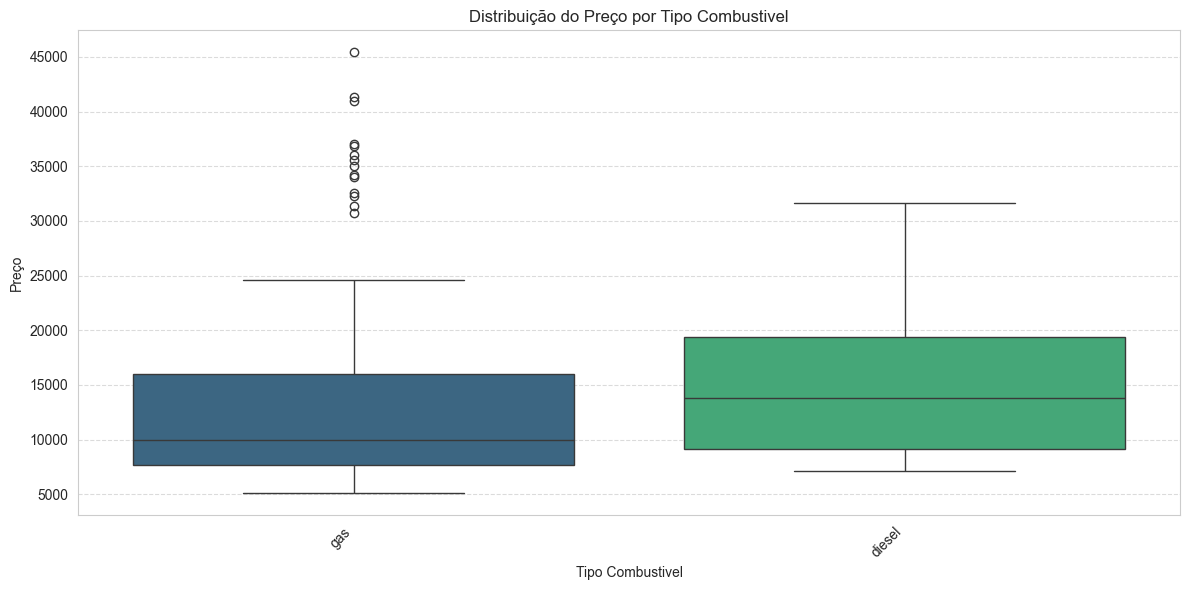

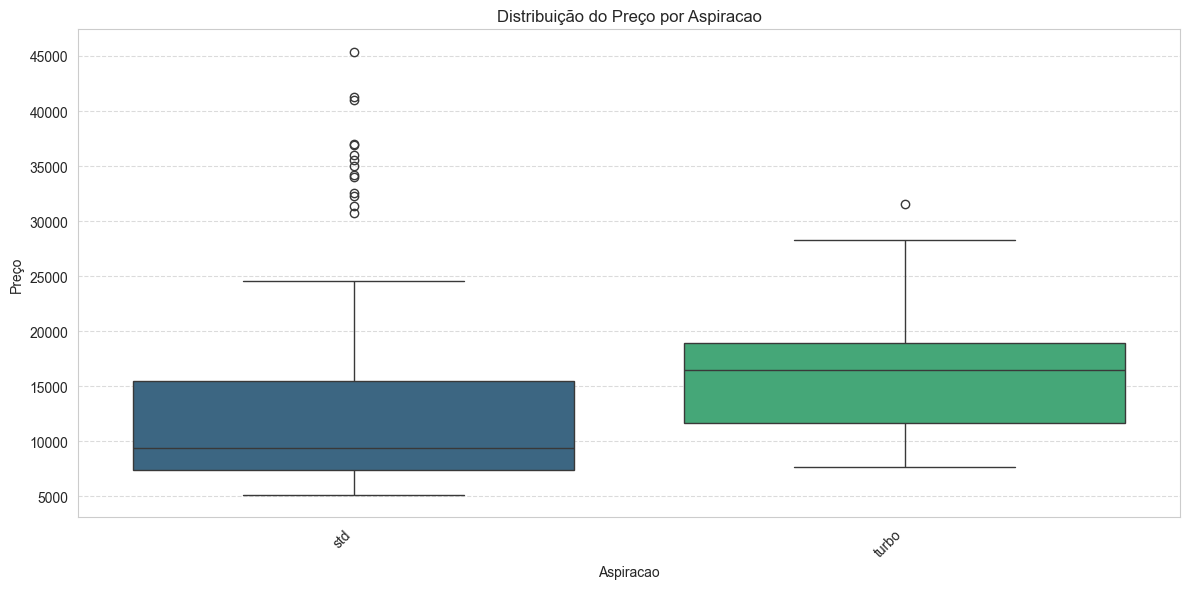

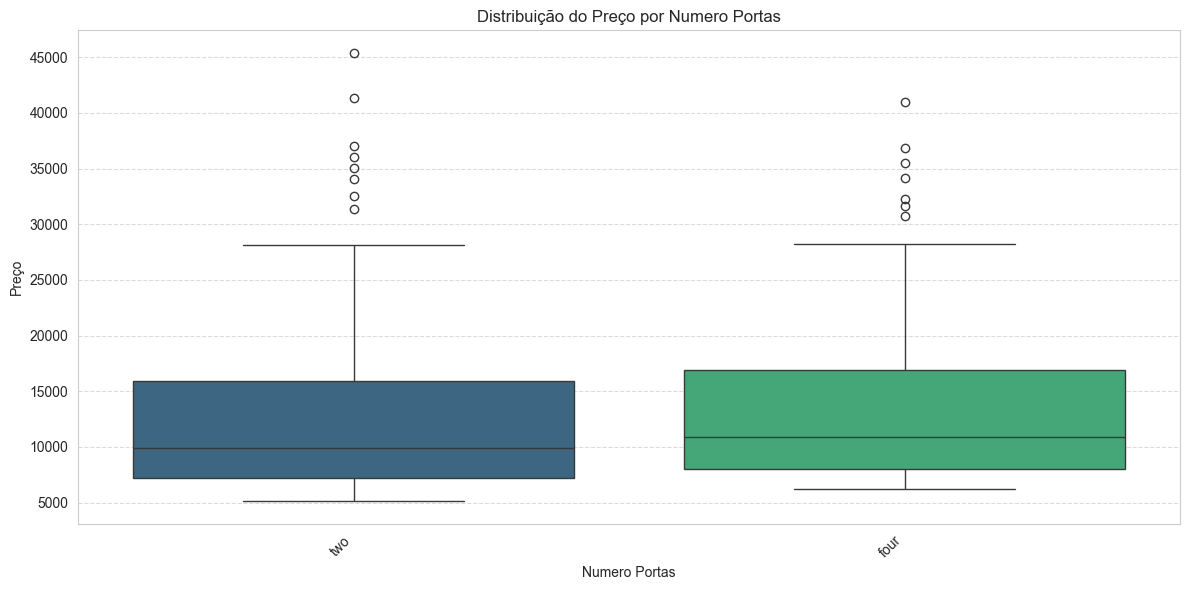

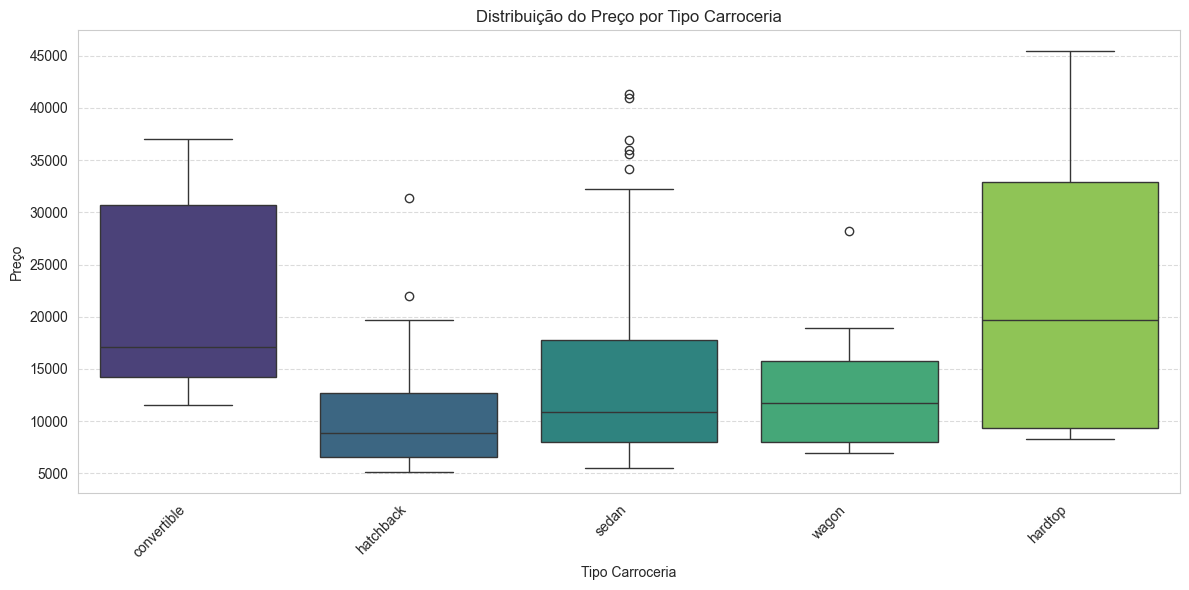

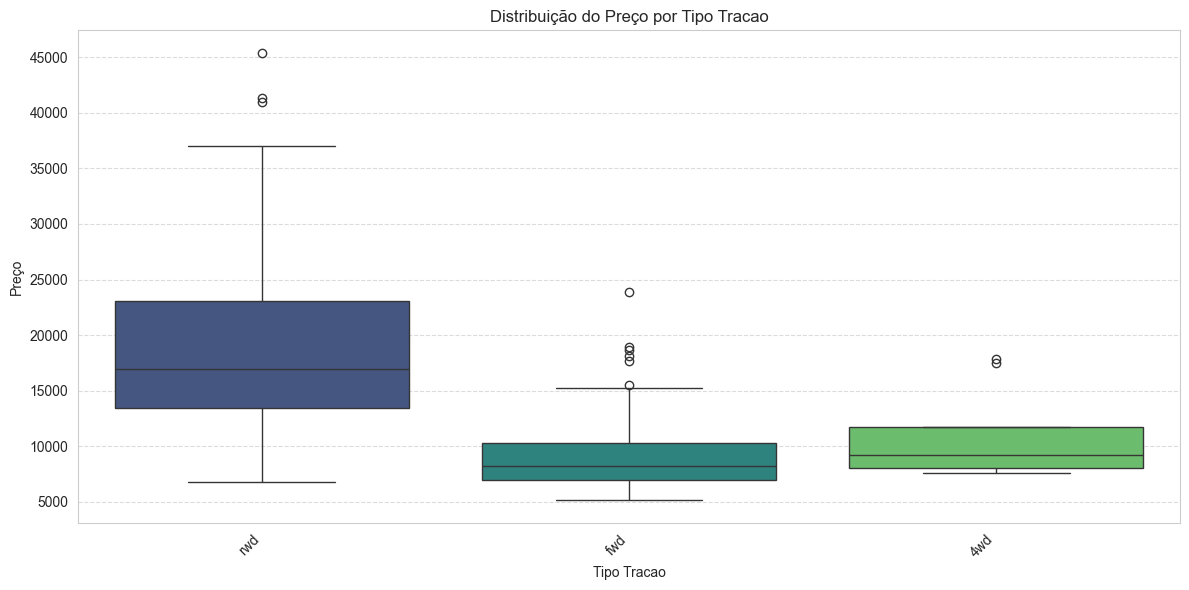

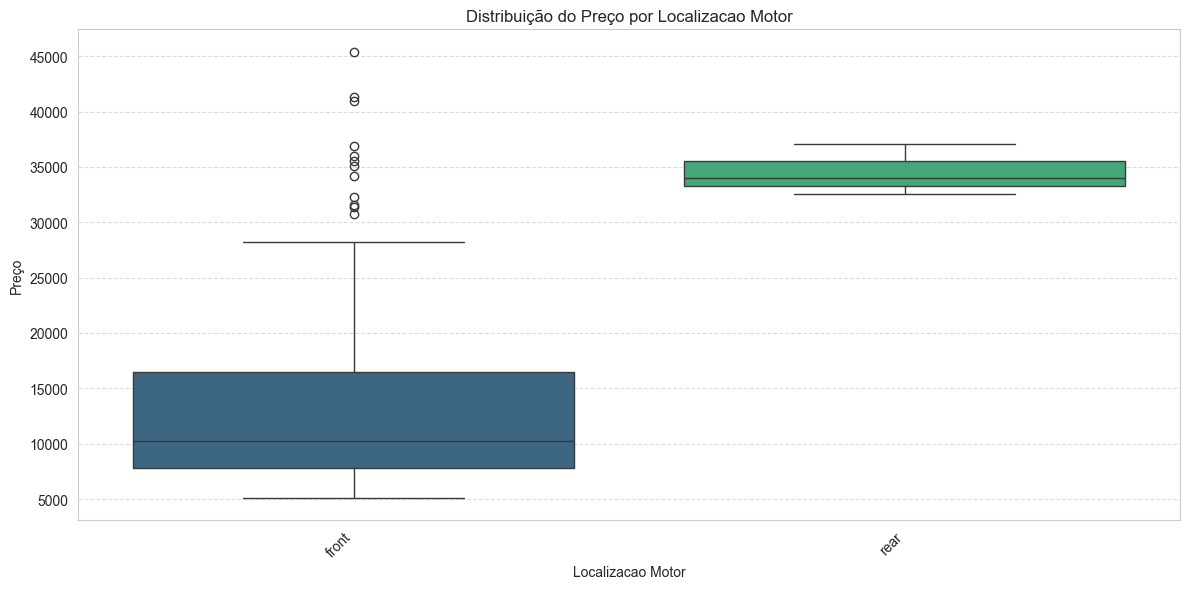

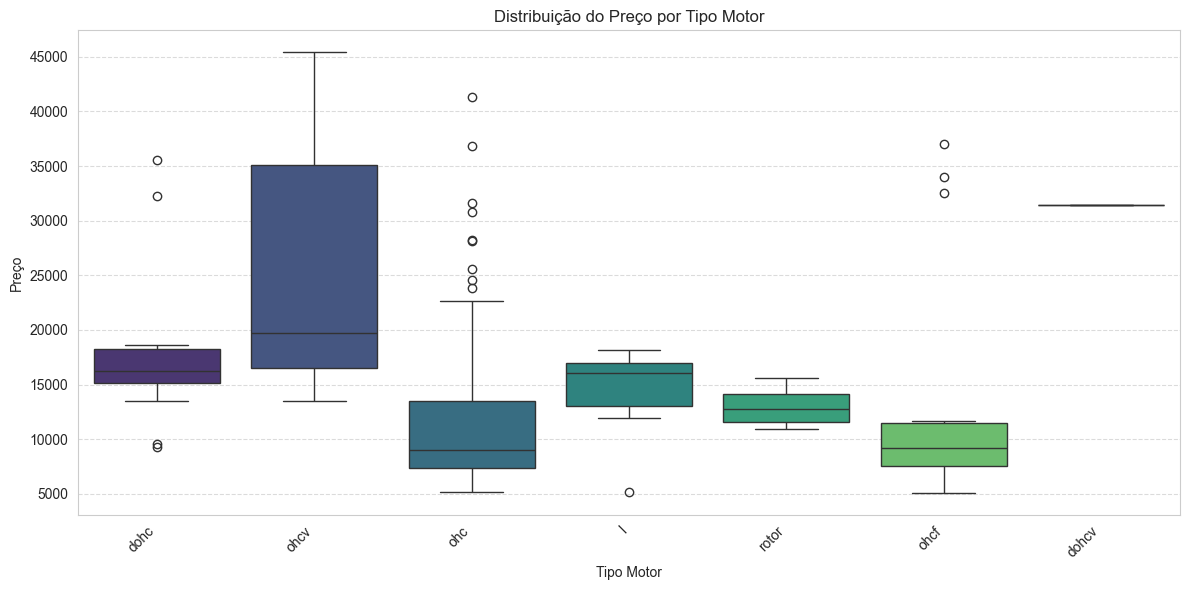

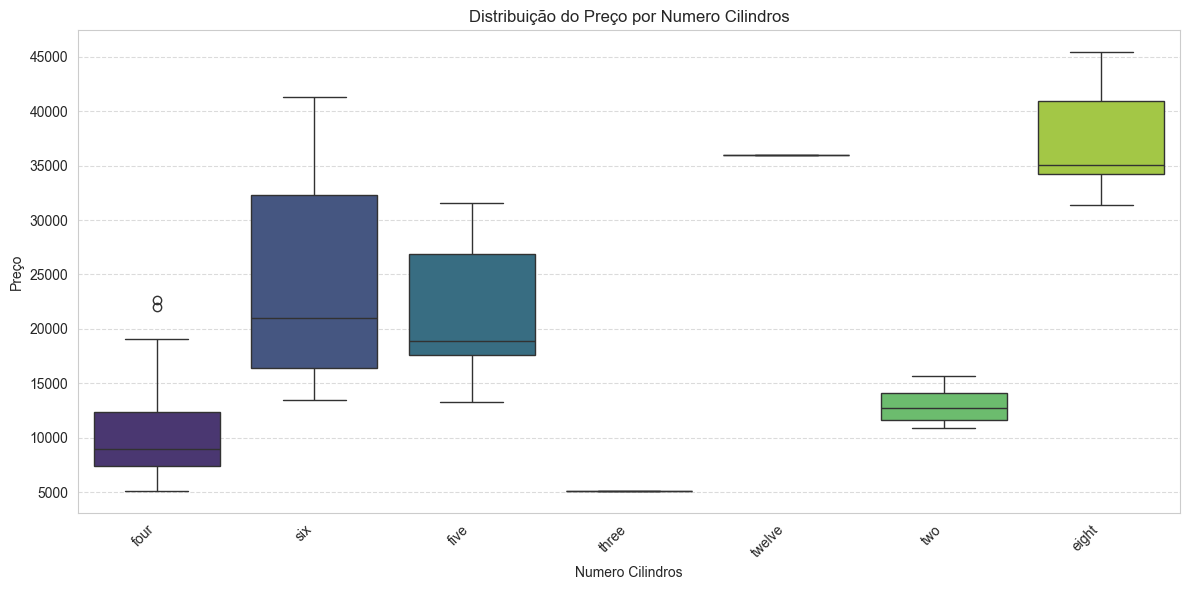

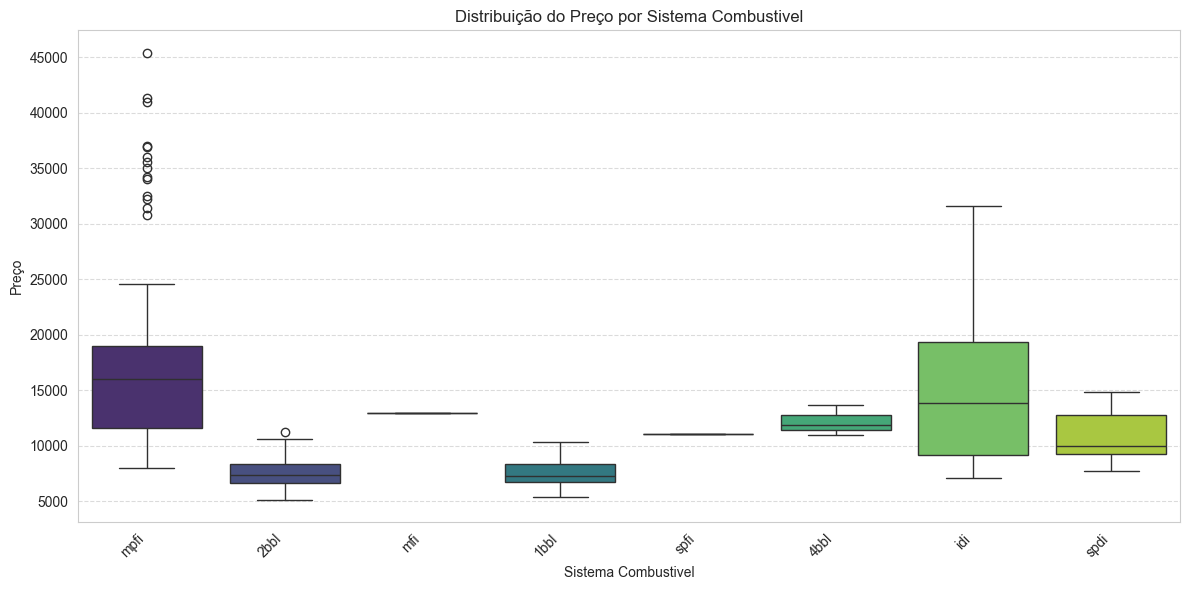

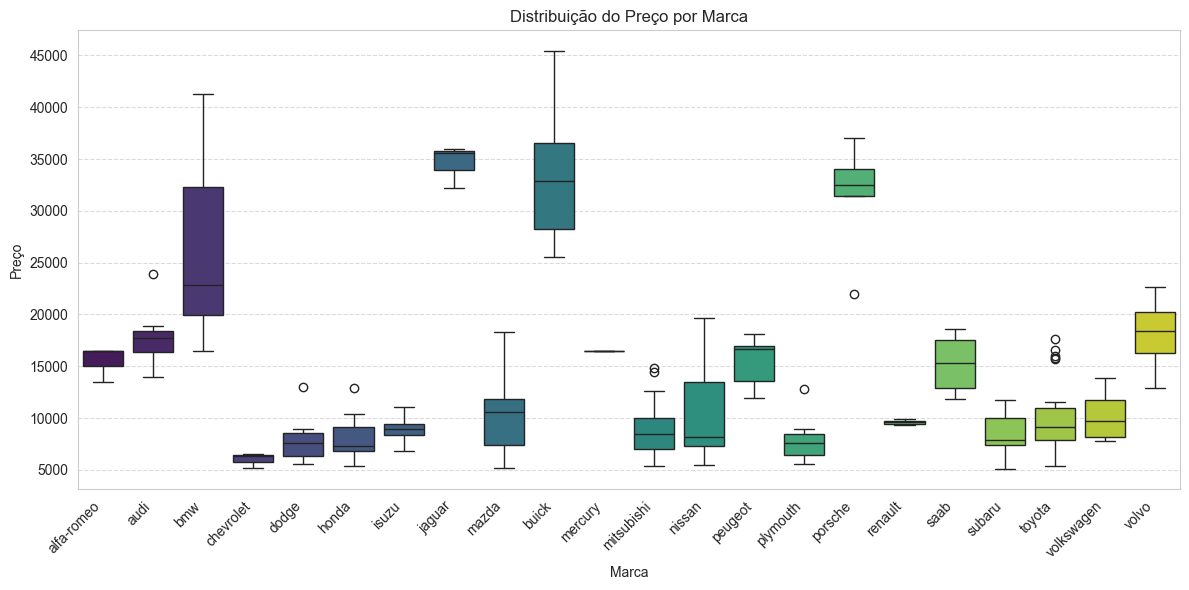

In [311]:
# Identificar colunas categóricas (object dtype)
categorical_cols = df.select_dtypes(include='object').columns

# Excluir 'nome_carro' pois possui muitos valores únicos e 'preco_USD' que é uma representação formatada
categorical_cols = categorical_cols.drop(['nome_carro', 'preco_USD'], errors='ignore')

# Gerar boxplots para cada variável categórica vs. 'preco'
for col in categorical_cols:
    plt.figure(figsize=(12, 6))
    # Adicionando hue=col e legend=False para evitar o FutureWarning do Seaborn
    sns.boxplot(x=col, y='preco', data=df, palette='viridis', hue=col, legend=False)
    plt.title(f'Distribuição do Preço por {col.replace('_', ' ').title()}')
    plt.xlabel(col.replace('_', ' ').title())
    plt.ylabel('Preço')
    plt.xticks(rotation=45, ha='right') # Rotaciona os rótulos do eixo x para melhor legibilidade
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

ETAPA 2 - TRATAMENTO DE DADOS PRECO_CARRO.CSV
# Análise exploratória de `preco_carro.csv`: correlação, não linearidade e multicolinearidade
Notebook consolidado, preparatório para a regressão linear.

**Roteiro**
1. Preparação e tipos das variáveis (conforme o dicionário de dados)
2. Correlação de Pearson entre as variáveis numéricas e `preco`
3. Gráficos de dispersão
4. Multicolinearidade entre as variáveis quantitativas
5. Multicolinearidade entre quantitativas e categóricas
6. Síntese e recomendações

**Arquivo necessário:** `preco_carro.csv` na mesma pasta do notebook.
**Bibliotecas:** pandas, numpy, matplotlib, seaborn, scipy, statsmodels, scikit-learn.

## 1. Preparação e tipos das variáveis

In [312]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, chi2_contingency
from sklearn.feature_selection import mutual_info_regression
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools import add_constant

sns.set_style('whitegrid')
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 50)

df = pd.read_csv('preco_carro.csv')
print(df.shape, '| nulos:', int(df.isna().sum().sum()), '| duplicadas:', int(df.duplicated().sum()))
df.head()

(205, 27) | nulos: 0 | duplicadas: 0


,ID_carro,simbolizacao_risco,nome_carro,tipo_combustivel,aspiracao,numero_portas,tipo_carroceria,tipo_tracao,localizacao_motor,distancia_entre_eixos,comprimento_carro,largura_carro,altura_carro,peso_em_ordem_de_marcha,tipo_motor,numero_cilindros,tamanho_motor,sistema_combustivel,diametro_cilindro,curso_pistao,taxa_compressao,potencia_hp,rpm_maximo,consumo_cidade_mpg,consumo_estrada_mpg,preco,marca
0,1,3,alfa-romeo giulia,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romeo
1,2,3,alfa-romeo stelvio,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romeo
2,3,1,alfa-romeo quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romeo
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,audi
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,audi


O **dicionário de dados** define os tipos:
- **Categóricas:** Classificação de Risco (`simbolizacao_risco`), Fabricante (`marca`), Combustível, Aspiração, Nº de Portas, Carroceria, Tração, Localização do Motor, Tipo de Motor, Nº de Cilindros e Sistema de Combustível - 
- **Numéricas:** as demais, exceto `preco` (variável alvo) e `ID_carro` (identificador).
- `nome_carro` não consta no dicionário e tem 142 valores distintos (funciona como identificador), então fica fora; `marca` já traz essa informação.

Atenção: `simbolizacao_risco` é inteira no CSV, mas **categórica** no dicionário, então **não entra** nas análises numéricas.

In [313]:
cat_cols = ['simbolizacao_risco', 'marca', 'tipo_combustivel', 'aspiracao', 'numero_portas',
            'tipo_carroceria', 'tipo_tracao', 'localizacao_motor', 'tipo_motor',
            'numero_cilindros', 'sistema_combustivel']
fora = ['ID_carro', 'nome_carro', 'preco']

num_cols = [c for c in df.select_dtypes(include='number').columns
            if c not in cat_cols + fora]          # 13 preditores quantitativos

df[cat_cols] = df[cat_cols].astype(str)

print(f'{len(num_cols)} quantitativas:', num_cols)
print(f'{len(cat_cols)} categóricas  :', cat_cols)
df[['preco']].describe().T.round(1)

13 quantitativas: ['distancia_entre_eixos', 'comprimento_carro', 'largura_carro', 'altura_carro', 'peso_em_ordem_de_marcha', 'tamanho_motor', 'diametro_cilindro', 'curso_pistao', 'taxa_compressao', 'potencia_hp', 'rpm_maximo', 'consumo_cidade_mpg', 'consumo_estrada_mpg']
11 categóricas  : ['simbolizacao_risco', 'marca', 'tipo_combustivel', 'aspiracao', 'numero_portas', 'tipo_carroceria', 'tipo_tracao', 'localizacao_motor', 'tipo_motor', 'numero_cilindros', 'sistema_combustivel']


,count,mean,std,min,25%,50%,75%,max
preco,205.0,13276.7,7988.9,5118.0,7788.0,10295.0,16503.0,45400.0


## 2. Correlação de Pearson: variáveis numéricas x `preco`

In [314]:
corr = df[num_cols + ['preco']].corr(method='pearson')

corr_alvo = (corr['preco'].drop('preco')
             .sort_values(key=abs, ascending=False)
             .to_frame('pearson_r'))
corr_alvo['r2'] = corr_alvo['pearson_r'] ** 2
pv = {c: pearsonr(df[c], df['preco'])[1] for c in corr_alvo.index}
corr_alvo['p_valor'] = pd.Series(pv)
corr_alvo['significativo_5%'] = corr_alvo['p_valor'] < 0.05
corr_alvo.round(4)

,pearson_r,r2,p_valor,significativo_5%
tamanho_motor,0.8741,0.7641,0.0000,True
peso_em_ordem_de_marcha,0.8353,0.6977,0.0000,True
potencia_hp,0.8081,0.6531,0.0000,True
largura_carro,0.7593,0.5766,0.0000,True
consumo_estrada_mpg,-0.6976,0.4866,0.0000,True
consumo_cidade_mpg,-0.6858,0.4703,0.0000,True
comprimento_carro,0.6829,0.4664,0.0000,True
distancia_entre_eixos,0.5778,0.3339,0.0000,True
diametro_cilindro,0.5532,0.3060,0.0000,True
altura_carro,0.1193,0.0142,0.0883,False


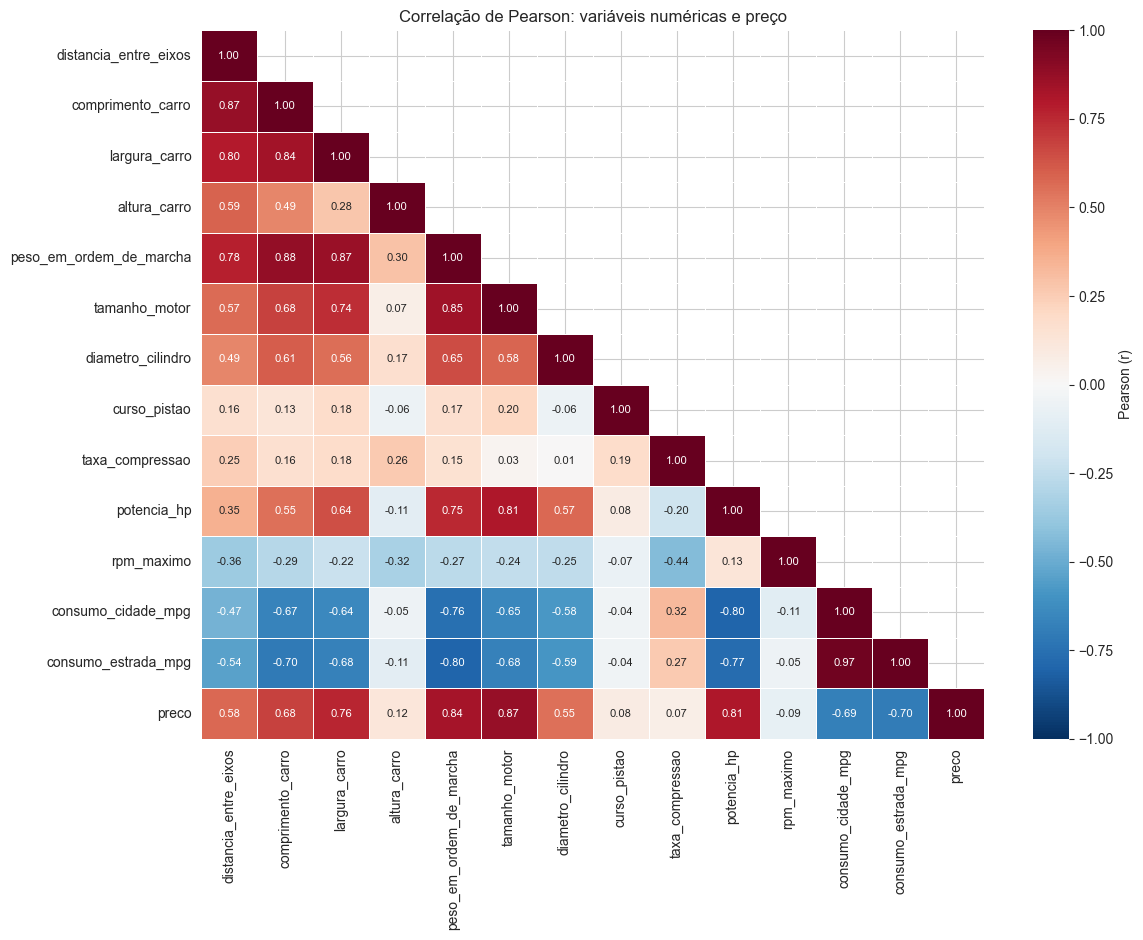

In [315]:
fig, ax = plt.subplots(figsize=(12, 9.5))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1,
            linewidths=.5, annot_kws={'size': 8}, cbar_kws={'label': 'Pearson (r)'}, ax=ax)
ax.set_title('Correlação de Pearson: variáveis numéricas e preço')
plt.tight_layout(); plt.show()

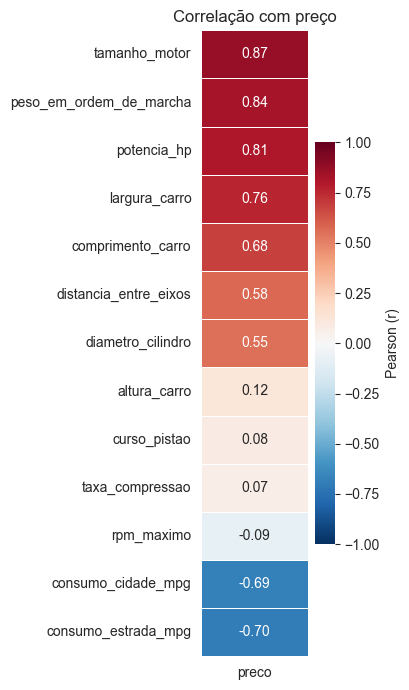

In [316]:
plt.figure(figsize=(4, 7))
sns.heatmap(corr[['preco']].drop('preco').sort_values('preco', ascending=False),
            annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1,
            linewidths=.5, cbar_kws={'label': 'Pearson (r)'})
plt.title('Correlação com preço')
plt.tight_layout(); plt.show()

Principais Insights de Correlação com a Variável Alvo (preco):
1. Forte Associação Positivatamanho_motor ($r = 0{,}87$): É a variável quantitativa de maior impacto linear direto sobre o preço. Motores de maior cilindrada correlacionam-se fortemente com veículos de valor elevado.peso_em_ordem_de_marcha ($r = 0{,}84$): Veículos mais pesados exigem estruturas e componentes mais robustos, influenciando diretamente o custo final.potencia_hp ($r = 0{,}81$): O desempenho em potência (horsepower) reflete o segmento e o valor do veículo.Dimensões do veículo (largura_carro: $r = 0{,}76$ e comprimento_carro: $r = 0{,}68$): Dimensões físicas maiores indicam categorias superiores (sedãs executivos/SUVs), encarecendo o produto.2. Forte Associação NegativaEficiência de Combustível (consumo_estrada_mpg: $r = -0{,}70$ e consumo_cidade_mpg: $r = -0{,}69$): Existe uma relação inversamente proporcional com o preço. Carros de alto valor tendem a priorizar desempenho e tamanho em detrimento da economia de combustível.3. Variáveis de Baixa Influência Linear Diretasimbolizacao_risco ($r = -0{,}08$), rpm_maximo ($r = -0{,}09$), curso_pistao ($r = 0{,}08$), taxa_compressao ($r = 0{,}07$) e altura_carro ($r = 0{,}12$): Apresentam correlações lineares fracas com a variável alvo.Diagnóstico de Multicolinearidade para Modelagem PreditivaDo ponto de vista de Ciência de Dados, o mapa de calor revela pontos críticos de multicolinearidade entre as variáveis preditoras:consumo_cidade_mpg vs. consumo_estrada_mpg ($r = 0{,}97$): Apresentam redundância quase perfeita. Recomenda-se manter apenas uma das duas ou criar uma métrica ponderada de consumo médio.comprimento_carro vs. distancia_entre_eixos ($r = 0{,}87$) e largura_carro ($r = 0{,}84$): Alta redundância dimensional.peso_em_ordem_de_marcha vs. tamanho_motor ($r = 0{,}85$) e potencia_hp vs. tamanho_motor ($r = 0{,}81$): Carros mais potentes e com motores maiores são naturalmente mais pesados.

## 3. Gráficos de dispersão
Em cada gráfico: **reta vermelha** (ajuste linear, o que o Pearson mede) e **curva verde tracejada** (LOWESS, ajuste suave sem assumir linearidade). Se as duas se afastarem, a relação não é bem linear.

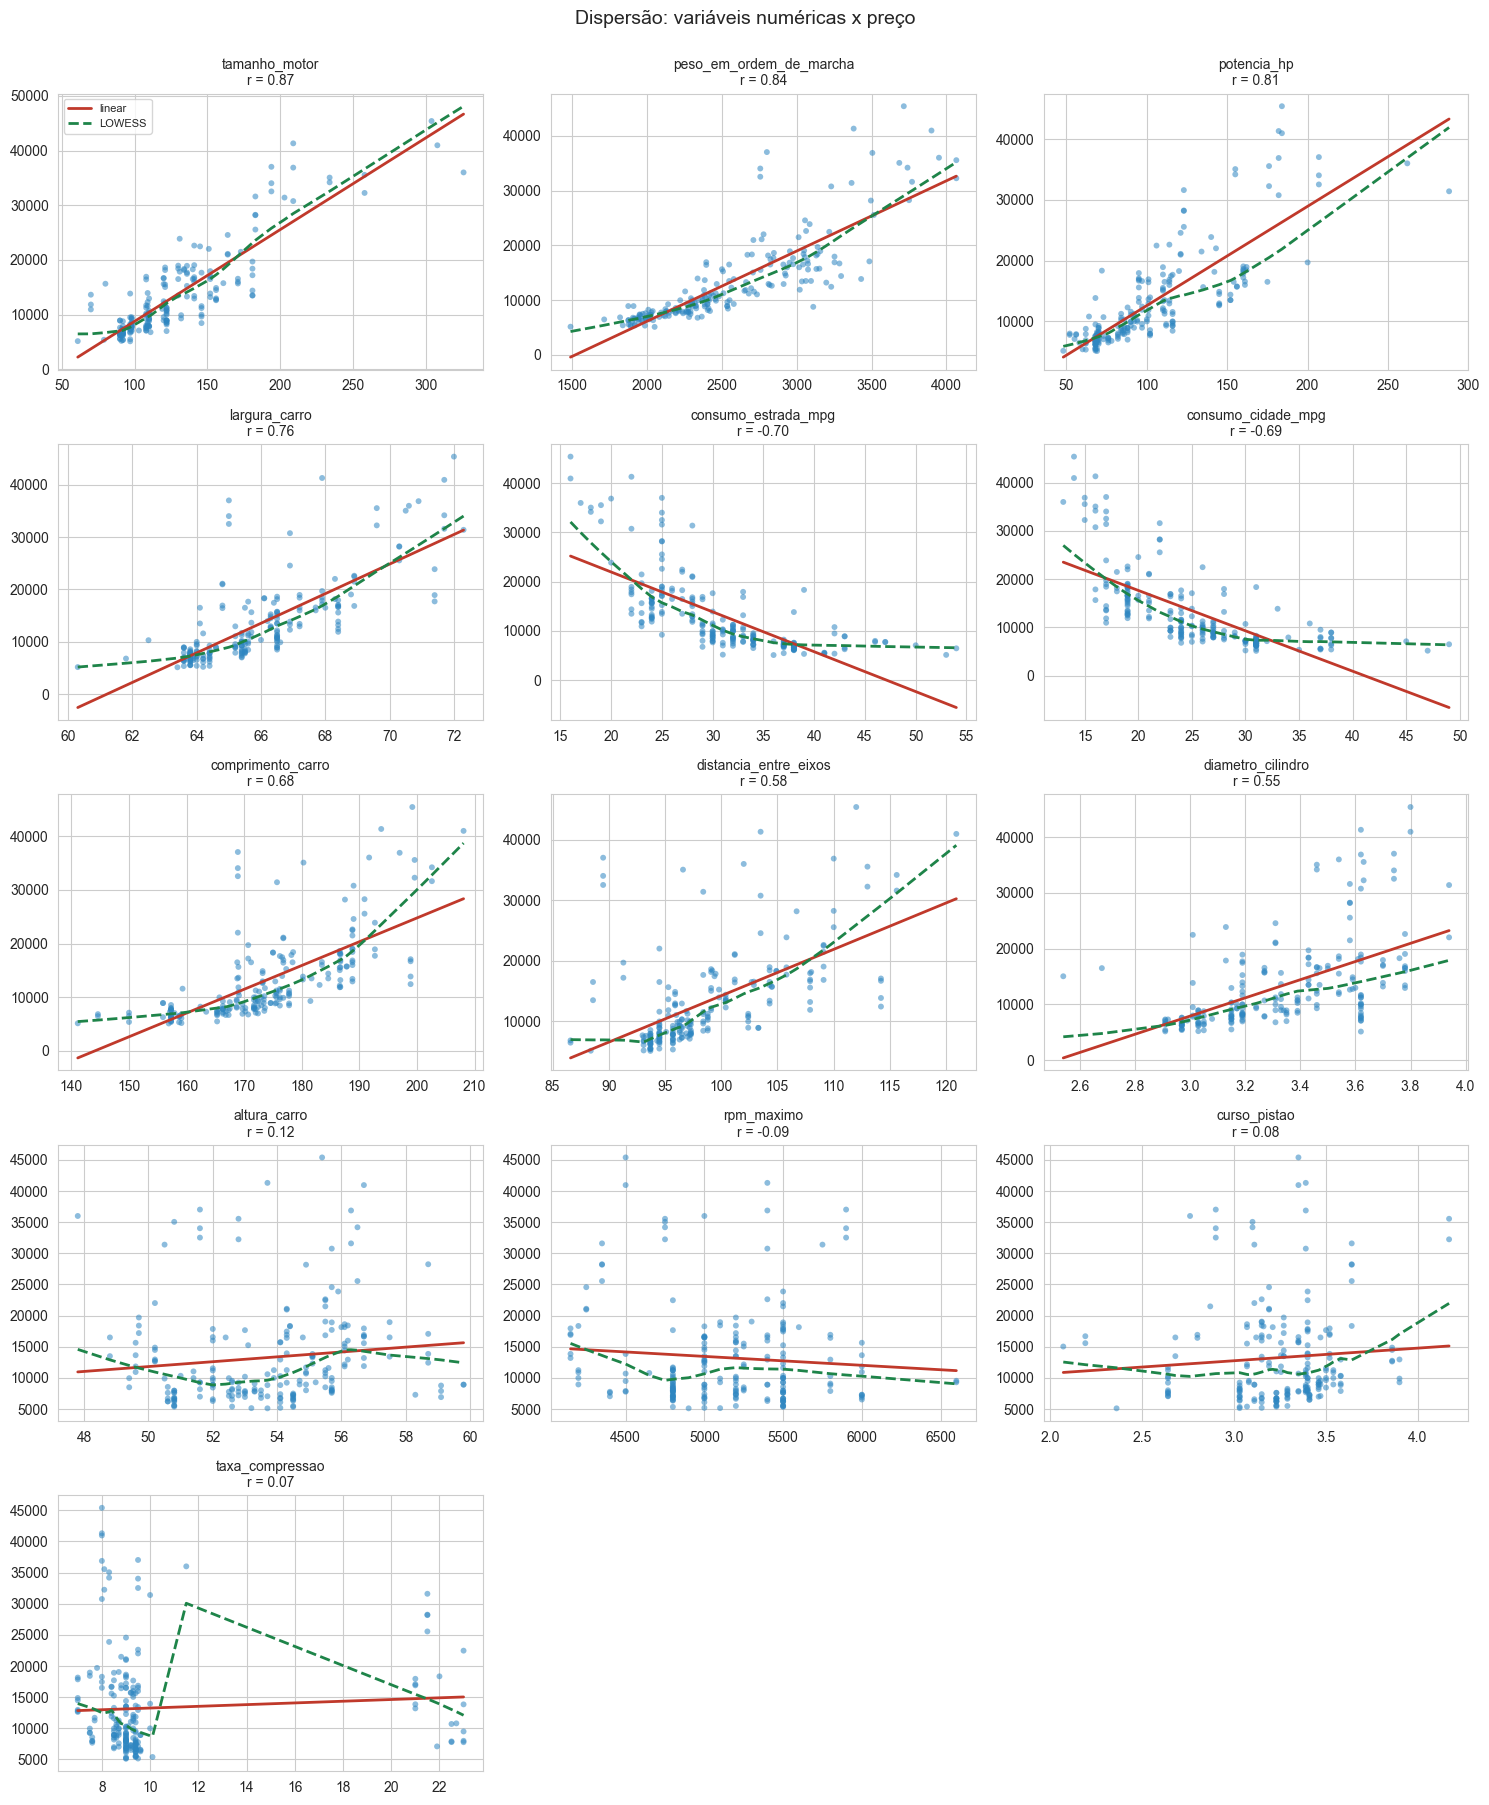

In [317]:
ordem = corr_alvo.index.tolist()          # da maior para a menor |r| com o preço

def dispersao(ax, d, x, y='preco', cor='#2e86c1'):
    ax.scatter(d[x], d[y], s=18, alpha=.55, color=cor, edgecolor='none')
    b, a = np.polyfit(d[x], d[y], 1)
    xs = np.linspace(d[x].min(), d[x].max(), 100)
    ax.plot(xs, a + b * xs, color='#c0392b', lw=2, label='linear')
    lw = lowess(d[y], d[x], frac=0.6)
    ax.plot(lw[:, 0], lw[:, 1], color='#1e8449', lw=2, ls='--', label='LOWESS')
    ax.set_title(f'{x}\nr = {pearsonr(d[x], d[y])[0]:.2f}', fontsize=10)
    ax.set_xlabel(''); ax.set_ylabel('')

def painel(vars_, y, cor, titulo):
    n = len(vars_); nc = 3; nr = int(np.ceil(n / nc))
    fig, axes = plt.subplots(nr, nc, figsize=(15, 3.6 * nr))
    axs = np.atleast_1d(axes).ravel()
    for ax, c in zip(axs, vars_):
        dispersao(ax, df, c, y=y, cor=cor)
    for ax in axs[n:]:
        ax.axis('off')
    axs[0].legend(loc='upper left', fontsize=8)
    fig.suptitle(titulo, fontsize=14, y=1.0)
    plt.tight_layout(); plt.show()

painel(ordem, 'preco', '#2e86c1', 'Dispersão: variáveis numéricas x preço')

## 5. Multicolinearidade entre as variáveis quantitativas
Os preditores quantitativos (sem `preco`, `ID_carro` e `simbolizacao_risco`) são avaliados por:
1. **VIF** e tolerância, por variável. Referência: **< 5** ok · **5 a 10** atenção · **> 10** grave.
2. **Matriz de correlação** (visão par a par).
3. **Índice de condição** (visão global). Referência: **< 10** ok · **10 a 30** moderado · **> 30** grave.
4. **Eliminação iterativa por VIF**.

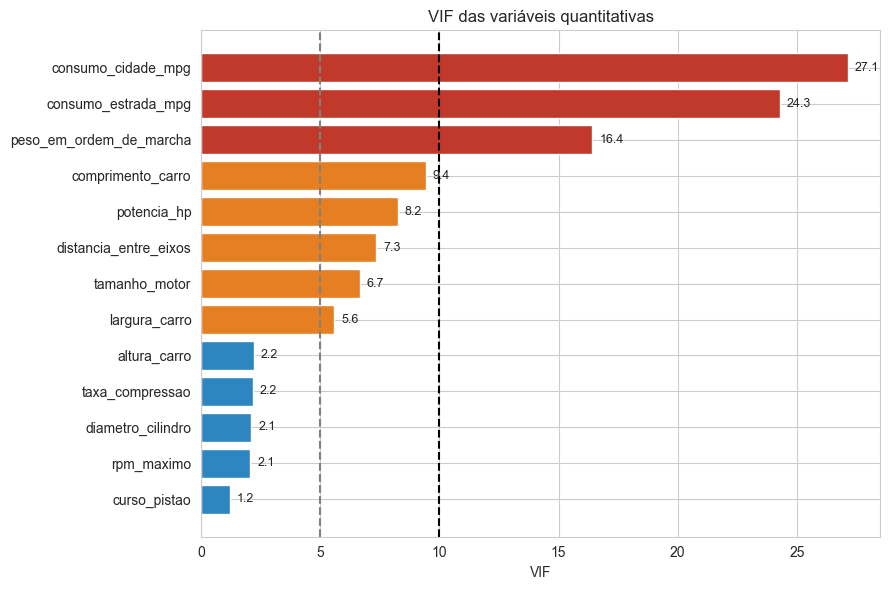

,variavel,VIF,tolerancia,R2_com_as_demais,diagnostico
0,consumo_cidade_mpg,27.129,0.037,0.963,grave
1,consumo_estrada_mpg,24.277,0.041,0.959,grave
2,peso_em_ordem_de_marcha,16.413,0.061,0.939,grave
3,comprimento_carro,9.423,0.106,0.894,atenção
4,potencia_hp,8.248,0.121,0.879,atenção
5,distancia_entre_eixos,7.341,0.136,0.864,atenção
6,tamanho_motor,6.659,0.150,0.850,atenção
7,largura_carro,5.586,0.179,0.821,atenção
8,altura_carro,2.206,0.453,0.547,ok
9,taxa_compressao,2.176,0.460,0.540,ok


In [318]:
Xq = df[num_cols].astype(float)

def calcula_vif(dados):
    Xc = add_constant(dados)
    v = pd.DataFrame({'variavel': dados.columns,
                      'VIF': [variance_inflation_factor(Xc.values, i + 1) for i in range(dados.shape[1])]})
    v['tolerancia'] = 1 / v['VIF']
    v['R2_com_as_demais'] = 1 - v['tolerancia']
    v['diagnostico'] = pd.cut(v['VIF'], [0, 5, 10, np.inf], labels=['ok', 'atenção', 'grave'])
    return v.sort_values('VIF', ascending=False).reset_index(drop=True)

vif = calcula_vif(Xq)

cores = vif['VIF'].apply(lambda v: '#c0392b' if v > 10 else '#e67e22' if v > 5 else '#2e86c1')
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(vif['variavel'][::-1], vif['VIF'][::-1], color=cores[::-1])
for y, v in enumerate(vif['VIF'][::-1]):
    ax.text(v + 0.3, y, f'{v:.1f}', va='center', fontsize=9)
ax.axvline(5, ls='--', c='gray'); ax.axvline(10, ls='--', c='black')
ax.set_xlabel('VIF'); ax.set_title('VIF das variáveis quantitativas')
plt.tight_layout(); plt.show()
vif.round(3)

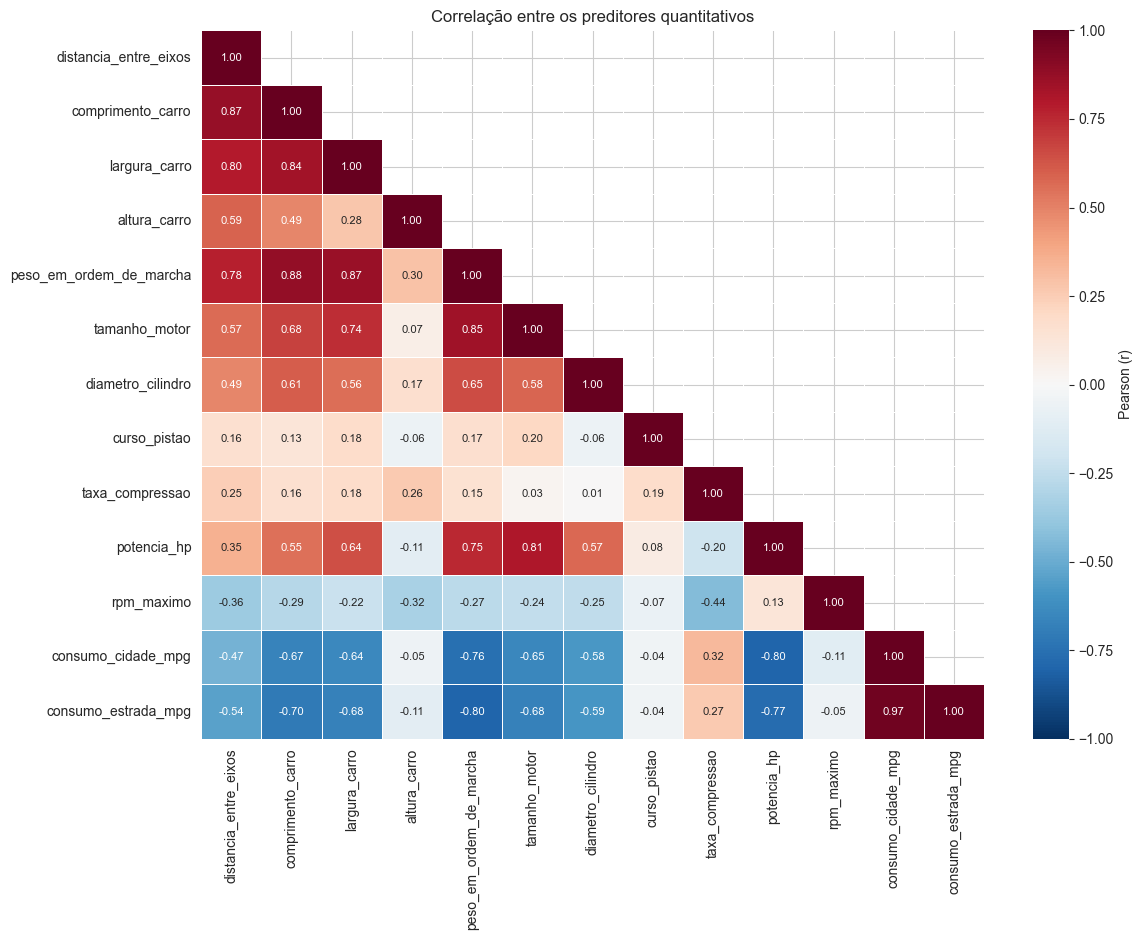

16 pares com |r| >= 0,70 (de 78 possíveis)


,var_1,var_2,r
0,consumo_cidade_mpg,consumo_estrada_mpg,0.971
1,comprimento_carro,peso_em_ordem_de_marcha,0.878
2,distancia_entre_eixos,comprimento_carro,0.875
3,largura_carro,peso_em_ordem_de_marcha,0.867
4,peso_em_ordem_de_marcha,tamanho_motor,0.851
5,comprimento_carro,largura_carro,0.841
6,tamanho_motor,potencia_hp,0.810
7,potencia_hp,consumo_cidade_mpg,-0.801
8,peso_em_ordem_de_marcha,consumo_estrada_mpg,-0.797
9,distancia_entre_eixos,largura_carro,0.795


In [319]:
corr_pred = Xq.corr()
fig, ax = plt.subplots(figsize=(12, 9.5))
mask = np.triu(np.ones_like(corr_pred, dtype=bool), k=1)
sns.heatmap(corr_pred, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1,
            linewidths=.5, annot_kws={'size': 8}, cbar_kws={'label': 'Pearson (r)'}, ax=ax)
ax.set_title('Correlação entre os preditores quantitativos')
plt.tight_layout(); plt.show()

pares = [(a, b, corr_pred.loc[a, b]) for i, a in enumerate(corr_pred.columns) for b in corr_pred.columns[i + 1:]]
pares = pd.DataFrame(pares, columns=['var_1', 'var_2', 'r'])
pares = pares.reindex(pares['r'].abs().sort_values(ascending=False).index)
altos = pares[pares['r'].abs() >= 0.70].reset_index(drop=True)
print(f'{len(altos)} pares com |r| >= 0,70 (de {len(pares)} possíveis)')
altos.round(3)

## 6. Multicolinearidade entre quantitativas e categóricas
Não há correlação de Pearson para categóricas, então usamos:
- **Cramér's V** (categórica x categórica): 0 a 1.
- **Razão de correlação η** (categórica x numérica): 0 a 1.
- **GVIF** para o conjunto misto (numéricas + dummies), com valor por variável.

### 6.1 Cramér's V

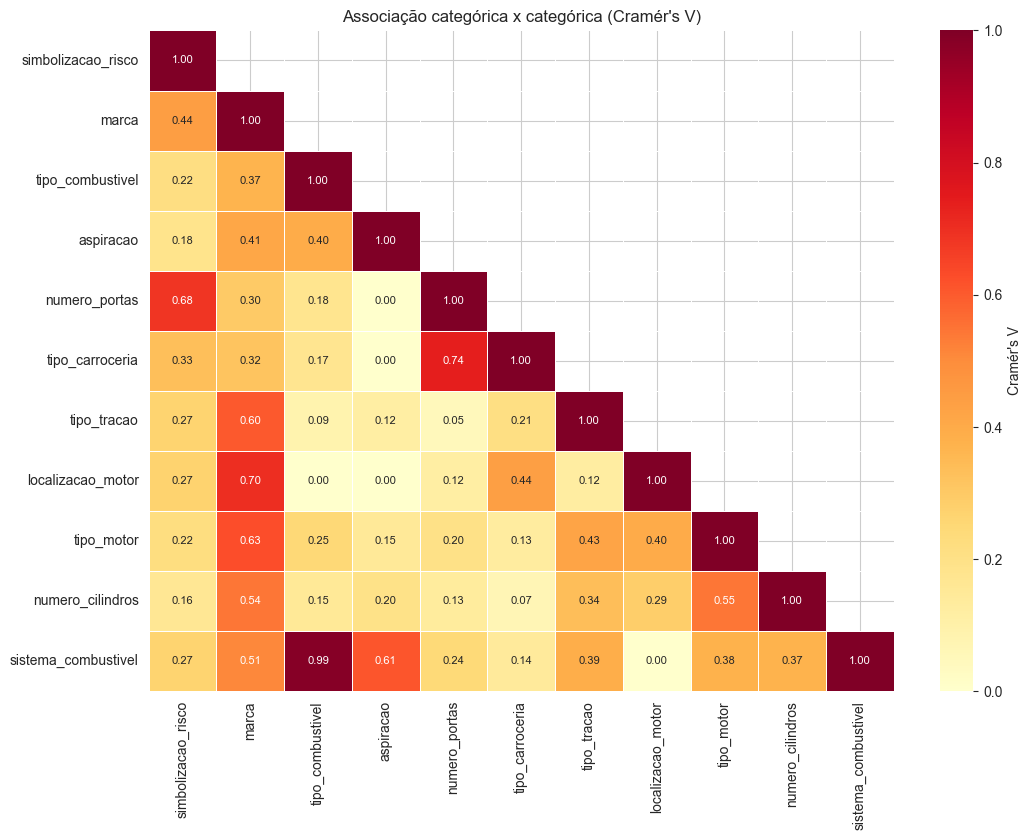

,cat_1,cat_2,V
0,tipo_combustivel,sistema_combustivel,0.985
1,numero_portas,tipo_carroceria,0.741
2,marca,localizacao_motor,0.703
3,simbolizacao_risco,numero_portas,0.684
4,marca,tipo_motor,0.629
5,aspiracao,sistema_combustivel,0.610
6,marca,tipo_tracao,0.603
7,tipo_motor,numero_cilindros,0.546
8,marca,numero_cilindros,0.544
9,marca,sistema_combustivel,0.510


In [320]:
def cramers_v(x, y):
    t = pd.crosstab(x, y)
    chi2 = chi2_contingency(t, correction=False)[0]
    n = t.values.sum(); r, k = t.shape
    phi2 = max(0, chi2 / n - (k - 1) * (r - 1) / (n - 1))
    rc, kc = r - (r - 1) ** 2 / (n - 1), k - (k - 1) ** 2 / (n - 1)
    d = min(kc - 1, rc - 1)
    return np.sqrt(phi2 / d) if d > 0 else np.nan

V = pd.DataFrame({b: {a: (1.0 if a == b else cramers_v(df[a], df[b])) for a in cat_cols} for b in cat_cols})

fig, ax = plt.subplots(figsize=(11, 8.5))
mask = np.triu(np.ones_like(V, dtype=bool), k=1)
sns.heatmap(V, mask=mask, annot=True, fmt='.2f', cmap='YlOrRd', vmin=0, vmax=1,
            linewidths=.5, annot_kws={'size': 8}, cbar_kws={'label': "Cramér's V"}, ax=ax)
ax.set_title("Associação categórica x categórica (Cramér's V)")
plt.tight_layout(); plt.show()

linhas = [(a, b, V.loc[a, b]) for i, a in enumerate(cat_cols) for b in cat_cols[i + 1:]]
top_v = pd.DataFrame(linhas, columns=['cat_1', 'cat_2', 'V']).sort_values('V', ascending=False).head(12).reset_index(drop=True)
top_v.round(3)

In [321]:
# Redundância perfeita: tipo_combustivel x sistema_combustivel
pd.crosstab(df['tipo_combustivel'], df['sistema_combustivel'])

sistema_combustivel,1bbl,2bbl,4bbl,idi,mfi,mpfi,spdi,spfi
tipo_combustivel,,,,,,,,
diesel,0,0,0,20,0,0,0,0
gas,11,66,3,0,1,94,9,1


### 6.2 Razão de correlação η (categórica x numérica)

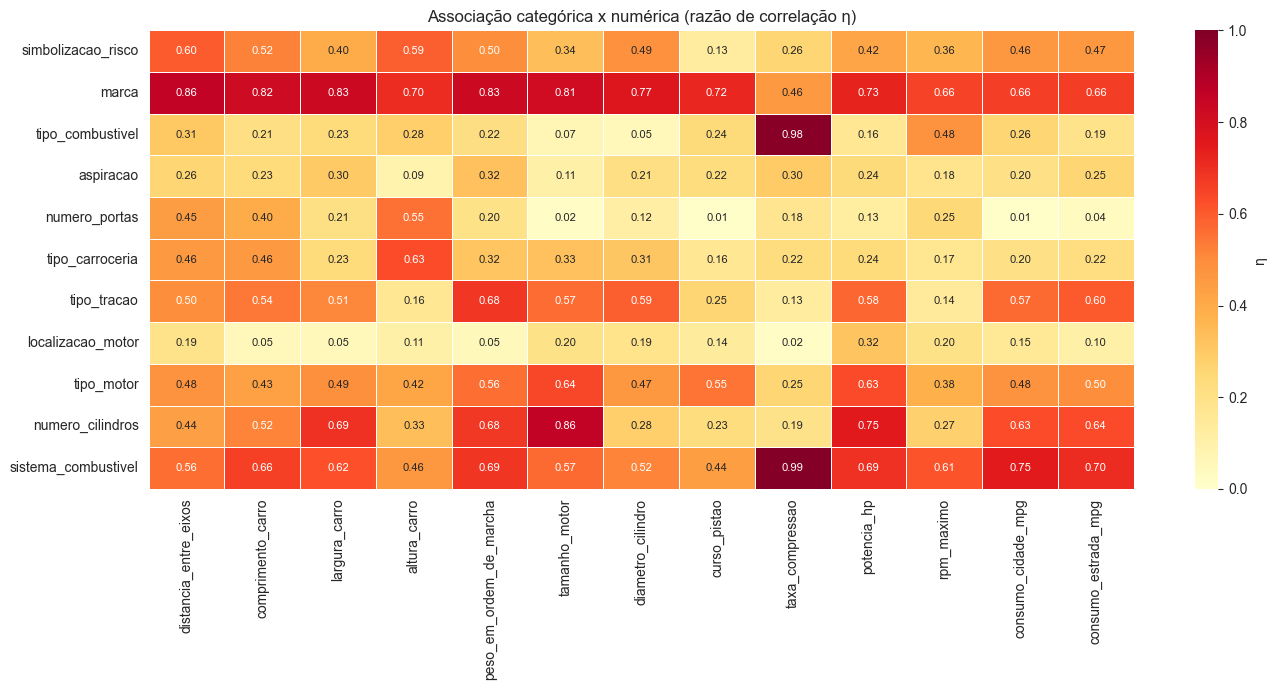

,categorica,numerica,eta
0,sistema_combustivel,taxa_compressao,0.989
1,tipo_combustivel,taxa_compressao,0.984
2,numero_cilindros,tamanho_motor,0.858
3,marca,distancia_entre_eixos,0.856
4,marca,peso_em_ordem_de_marcha,0.827
5,marca,largura_carro,0.825
6,marca,comprimento_carro,0.824
7,marca,tamanho_motor,0.815
8,marca,diametro_cilindro,0.767
9,numero_cilindros,potencia_hp,0.753


In [322]:
def eta(cat, num):
    ssb = sum(len(v) * (v.mean() - num.mean()) ** 2 for _, v in num.groupby(cat))
    return np.sqrt(ssb / ((num - num.mean()) ** 2).sum())

E = pd.DataFrame({n: {c: eta(df[c], df[n]) for c in cat_cols} for n in num_cols})

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(E, annot=True, fmt='.2f', cmap='YlOrRd', vmin=0, vmax=1,
            linewidths=.5, annot_kws={'size': 8}, cbar_kws={'label': 'η'}, ax=ax)
ax.set_title('Associação categórica x numérica (razão de correlação η)')
plt.tight_layout(); plt.show()

top_eta = (E.stack().rename('eta').reset_index()
             .rename(columns={'level_0': 'categorica', 'level_1': 'numerica'})
             .sort_values('eta', ascending=False).head(12).reset_index(drop=True))
top_eta.round(3)

### 6.3 GVIF (numéricas + categóricas)
O VIF comum não serve para dummies, então usa-se o **GVIF**, com **GVIF^(1/(2·gl))** para comparar variáveis com números diferentes de níveis. Limites equivalentes: **2,24** (VIF = 5) e **3,16** (VIF = 10).

Cuidados antes de calcular:
- **Níveis raros** (< 5% das linhas) são agrupados em `outros`.
- **Redundância perfeita** (Cramér's V ≥ 0,95) torna a matriz singular; remove-se a variável com mais níveis.

In [323]:
def agrupar_raros(d, cols, min_frac=0.05):
    d = d.copy()
    for c in cols:
        freq = d[c].value_counts(normalize=True)
        raros = freq[freq < min_frac].index
        if len(raros) > 1 or (len(raros) == 1 and d[c].nunique() > 2):
            d[c] = d[c].where(~d[c].isin(raros), 'outros')
    return d

def remover_redundantes(d, cols, limite=0.95):
    removidas = []; cols = list(cols)
    for i, a in enumerate(cols):
        for b in cols[i + 1:]:
            if a in removidas or b in removidas:
                continue
            if cramers_v(d[a], d[b]) >= limite:
                drop = a if d[a].nunique() >= d[b].nunique() else b
                removidas.append(drop)
                print(f'  redundância perfeita: {a} x {b} (V >= {limite}) -> removendo {drop}')
    return [c for c in cols if c not in removidas]

def gvif(d, num, cats):
    blocos, partes = {}, []
    for n in num:
        blocos[n] = [n]; partes.append(d[[n]].astype(float))
    for c in cats:
        dm = pd.get_dummies(d[c], prefix=c, drop_first=True).astype(float)
        blocos[c] = list(dm.columns); partes.append(dm)
    Xd = pd.concat(partes, axis=1)
    R = np.corrcoef(Xd.values, rowvar=False)
    nomes = list(Xd.columns); idx = {n: i for i, n in enumerate(nomes)}
    posto = np.linalg.matrix_rank(Xd.values - Xd.values.mean(0))
    _, logdet = np.linalg.slogdet(R)
    saida = []
    for b, cl in blocos.items():
        ii = [idx[c] for c in cl]; jj = [i for i in range(len(nomes)) if i not in ii]
        _, l1 = np.linalg.slogdet(R[np.ix_(ii, ii)])
        _, l2 = np.linalg.slogdet(R[np.ix_(jj, jj)])
        g = np.exp(l1 + l2 - logdet)
        saida.append((b, 'numérica' if b in num else 'categórica', len(cl), g, g ** (1 / (2 * len(cl)))))
    t = pd.DataFrame(saida, columns=['variavel', 'tipo', 'gl', 'GVIF', 'GVIF_ajust'])
    t['diagnostico'] = pd.cut(t['GVIF_ajust'], [-np.inf, 2.24, 3.16, np.inf], labels=['ok', 'atenção', 'grave'])
    return t.sort_values('GVIF_ajust', ascending=False).reset_index(drop=True), posto, Xd.shape[1]

print('Verificando redundâncias perfeitas...')
cats_ok = remover_redundantes(df, cat_cols)
df_g = agrupar_raros(df, cats_ok)

cats_A = [c for c in cats_ok if c != 'marca']          # Cenário A: sem marca
res_A, posto_A, p_A = gvif(df_g, num_cols, cats_A)
print(f'\nCenário A (sem marca) | posto {posto_A}/{p_A} colunas')
res_A.round(2)

Verificando redundâncias perfeitas...
  redundância perfeita: tipo_combustivel x sistema_combustivel (V >= 0.95) -> removendo sistema_combustivel

Cenário A (sem marca) | posto 35/35 colunas


,variavel,tipo,gl,GVIF,GVIF_ajust,diagnostico
0,tipo_combustivel,categórica,1,114.10,10.68,grave
1,taxa_compressao,numérica,1,104.61,10.23,grave
2,consumo_cidade_mpg,numérica,1,38.58,6.21,grave
3,consumo_estrada_mpg,numérica,1,35.91,5.99,grave
4,tamanho_motor,numérica,1,34.04,5.83,grave
5,peso_em_ordem_de_marcha,numérica,1,30.43,5.52,grave
6,potencia_hp,numérica,1,18.52,4.30,grave
7,comprimento_carro,numérica,1,14.84,3.85,grave
8,distancia_entre_eixos,numérica,1,14.65,3.83,grave
9,largura_carro,numérica,1,10.30,3.21,grave


In [324]:
res_B, posto_B, p_B = gvif(df_g, num_cols, cats_ok)    # Cenário B: com marca
print(f'Cenário B (com marca) | posto {posto_B}/{p_B} colunas')
if posto_B < p_B:
    print('ATENÇÃO: matriz rank-deficiente (colinearidade exata); os GVIF abaixo são instáveis.')
res_B.round(2)

Cenário B (com marca) | posto 43/44 colunas
ATENÇÃO: matriz rank-deficiente (colinearidade exata); os GVIF abaixo são instáveis.


,variavel,tipo,gl,GVIF,GVIF_ajust,diagnostico
0,localizacao_motor,categórica,1,8.792739e+13,9376960.60,grave
1,tipo_motor,categórica,5,9.006710e+17,62.44,grave
2,tipo_combustivel,categórica,1,1.314600e+02,11.47,grave
3,taxa_compressao,numérica,1,1.301400e+02,11.41,grave
4,marca,categórica,9,1.298819e+18,10.15,grave
5,tamanho_motor,numérica,1,4.464000e+01,6.68,grave
6,consumo_cidade_mpg,numérica,1,4.366000e+01,6.61,grave
7,consumo_estrada_mpg,numérica,1,4.188000e+01,6.47,grave
8,peso_em_ordem_de_marcha,numérica,1,3.260000e+01,5.71,grave
9,potencia_hp,numérica,1,2.337000e+01,4.83,grave


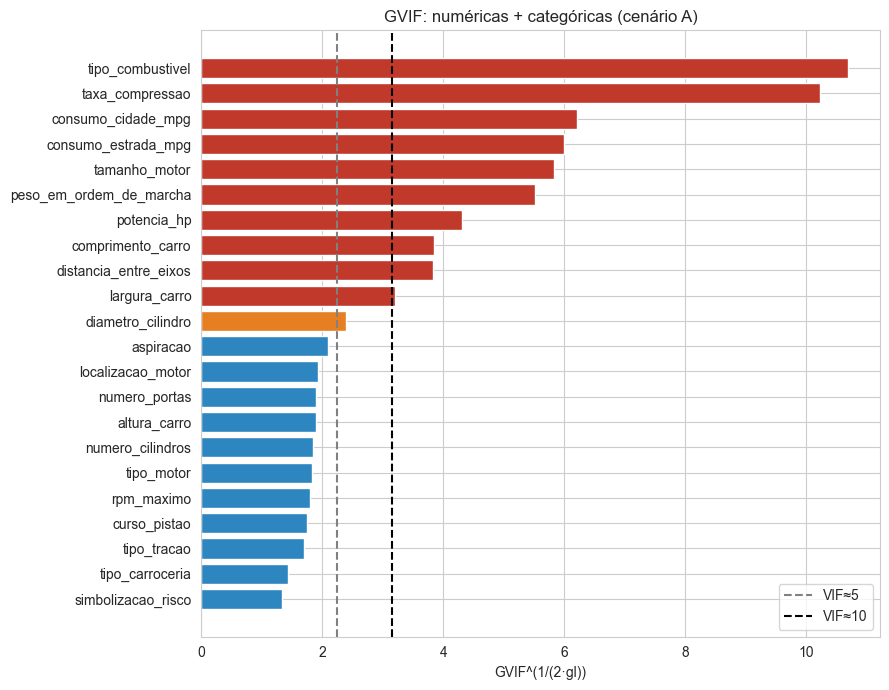

In [325]:
res = res_A
fig, ax = plt.subplots(figsize=(9, 7))
cores = res['diagnostico'].map({'ok': '#2e86c1', 'atenção': '#e67e22', 'grave': '#c0392b'}).astype(str)
ax.barh(res['variavel'][::-1], res['GVIF_ajust'][::-1], color=cores[::-1])
ax.axvline(2.24, ls='--', c='gray', label='VIF≈5'); ax.axvline(3.16, ls='--', c='black', label='VIF≈10')
ax.set_xlabel('GVIF^(1/(2·gl))'); ax.set_title('GVIF: numéricas + categóricas (cenário A)')
ax.legend(); plt.tight_layout(); plt.show()

## 7. Síntese e recomendações
Os valores abaixo são gerados pelo código a partir dos resultados acima.

1) CORRELAÇÃO COM O PREÇO
   Fraca: curso_pistao, rpm_maximo
   Linear forte: peso_em_ordem_de_marcha, tamanho_motor, potencia_hp, largura_carro, consumo_estrada_mpg, consumo_cidade_mpg, comprimento_carro, distancia_entre_eixos, diametro_cilindro
   Não linear / outra forma: altura_carro, taxa_compressao

2) MULTICOLINEARIDADE ENTRE QUANTITATIVAS
   VIF > 10  : consumo_cidade_mpg, consumo_estrada_mpg, peso_em_ordem_de_marcha
   VIF 5 a 10: comprimento_carro, potencia_hp, distancia_entre_eixos, tamanho_motor, largura_carro
   Pares com |r| >= 0,70: 16 de 78
   Número de condição: 18.4
   Remover p/ VIF <= 10: ['consumo_cidade_mpg', 'peso_em_ordem_de_marcha']
   Remover p/ VIF <= 5 : ['consumo_cidade_mpg', 'peso_em_ordem_de_marcha', 'comprimento_carro', 'potencia_hp']

3) QUANTITATIVAS x CATEGÓRICAS
   V = 0.99: tipo_combustivel x sistema_combustivel
   V = 0.74: numero_portas x tipo_carroceria
   V = 0.70: marca x localizacao_motor
   V = 0.68: simbolizacao_risco x numero_portas
   V = 0.63: marca x tipo_motor
   V = 0.61: aspiracao x sistema_combustivel
   V = 0.60: marca x tipo_tracao
   V = 0.55: tipo_motor x numero_cilindros
   V = 0.54: marca x numero_cilindros
   V = 0.51: marca x sistema_combustivel
   η = 0.99: sistema_combustivel x taxa_compressao
   η = 0.98: tipo_combustivel x taxa_compressao
   η = 0.86: numero_cilindros x tamanho_motor
   η = 0.86: marca x distancia_entre_eixos
   η = 0.83: marca x peso_em_ordem_de_marcha
   η = 0.83: marca x largura_carro
   η = 0.82: marca x comprimento_carro
   η = 0.81: marca x tamanho_motor
   GVIF (cenário A) acima de VIF≈5: tipo_combustivel, taxa_compressao, consumo_cidade_mpg, consumo_estrada_mpg, tamanho_motor, peso_em_ordem_de_marcha, potencia_hp, comprimento_carro, distancia_entre_eixos, largura_carro, diametro_cilindro

Limite VIF = 10 -> removidas: ['consumo_cidade_mpg', 'peso_em_ordem_de_marcha']
Limite VIF = 5  -> removidas: ['consumo_cidade_mpg', 'peso_em_ordem_de_marcha', 'comprimento_carro', 'potencia_hp']
original	limite 10	

### Recomendações para a regressão
- **Consumo:** manter apenas um entre `consumo_cidade_mpg` e `consumo_estrada_mpg` (ou usar a média dos dois).
- **Combustível:** descartar `sistema_combustivel` (redundante com `tipo_combustivel`). `taxa_compressao` e `tipo_combustivel` carregam informação muito parecida (η ≈ 0,98).
- **Bloco tamanho/peso/motor:** escolher representantes, ou usar PCA ou regularização (Ridge/Lasso). Remover peso e potência por VIF pode custar poder preditivo, porque estão entre as mais correlacionadas com o preço.
- **Alvo:** testar `log(preco)`, que reduz a assimetria e melhora a linearidade.
- **Relações não lineares:** `altura_carro` pode precisar de termo quadrático; `taxa_compressao` faz mais sentido via `tipo_combustivel`.
- **Não excluir variáveis só pelo r baixo com o alvo:** decidir depois de ajustar o modelo (coeficientes, R² ajustado, AIC/BIC, validação cruzada).
- **Categóricas raras:** agrupar níveis com poucos carros antes de criar dummies; usar `marca` com cautela (22 níveis, vários com 1 a 3 carros).

# ==========================================================
# ETAPA 3 - REGRESSÃO LINEAR MÚLTIPLA
# Variável alvo: preco
# ==========================================================

MODELO 1


In [326]:
# ==========================================================
# 16. MODELO OLS 1 - AVALIAÇÃO COMPLETA
# FEATURES PADRONIZADAS
# ==========================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from statsmodels.stats.diagnostic import het_breuschpagan
from scipy.stats import shapiro


# ==========================================================
# 16.1 DEFINIR FEATURES E TARGET
# ==========================================================

features_modelo_1 = [
    "tamanho_motor",
    "taxa_compressao",
    "diametro_cilindro",
    "rpm_maximo"
]

target = "preco"


# ==========================================================
# 16.2 CRIAR DATAFRAME
# ==========================================================

df_modelo_1 = df[
    features_modelo_1 + [target]
].copy()


# ==========================================================
# 16.3 REMOVER VALORES AUSENTES
# ==========================================================

df_modelo_1 = df_modelo_1.dropna()

print("Quantidade de observações:")
print(len(df_modelo_1))


# ==========================================================
# 16.4 SEPARAR X E Y
# ==========================================================

X = df_modelo_1[features_modelo_1]

y = df_modelo_1[target]


# ==========================================================
# 16.5 SEPARAR TREINO E TESTE
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


print("\nQuantidade de observações:")
print("Treino:", len(X_train))
print("Teste :", len(X_test))


# ==========================================================
# 16.6 PADRONIZAÇÃO
# ==========================================================

scaler = StandardScaler()

X_train_pad = scaler.fit_transform(X_train)

X_test_pad = scaler.transform(X_test)


# ==========================================================
# 16.7 OLS COM STATSmodels
# ==========================================================

X_train_ols = sm.add_constant(X_train_pad)

X_test_ols = sm.add_constant(X_test_pad)


modelo_ols_1 = sm.OLS(
    y_train,
    X_train_ols
).fit()


# ==========================================================
# 16.8 RESUMO DO MODELO
# ==========================================================

print("\n")
print("=" * 70)
print("RESUMO DO MODELO OLS")
print("=" * 70)

print(modelo_ols_1.summary())


# ==========================================================
# 16.9 PREVISÕES
# ==========================================================

y_pred_train = modelo_ols_1.predict(X_train_ols)

y_pred_test = modelo_ols_1.predict(X_test_ols)


# ==========================================================
# 16.10 MÉTRICAS DE TREINO
# ==========================================================

mae_train = mean_absolute_error(
    y_train,
    y_pred_train
)

rmse_train = np.sqrt(
    mean_squared_error(
        y_train,
        y_pred_train
    )
)

r2_train = r2_score(
    y_train,
    y_pred_train
)


# ==========================================================
# 16.11 MÉTRICAS DE TESTE
# ==========================================================

mae_test = mean_absolute_error(
    y_test,
    y_pred_test
)

rmse_test = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_test
    )
)

r2_test = r2_score(
    y_test,
    y_pred_test
)


# ==========================================================
# 16.12 COMPARAR TREINO E TESTE
# ==========================================================

resultados = pd.DataFrame({
    "Metrica": [
        "MAE",
        "RMSE",
        "R²"
    ],

    "Treino": [
        mae_train,
        rmse_train,
        r2_train
    ],

    "Teste": [
        mae_test,
        rmse_test,
        r2_test
    ]
})


print("\n")
print("=" * 70)
print("RESULTADOS - TREINO x TESTE")
print("=" * 70)

display(resultados.round(4))


# ==========================================================
# 16.13 RESÍDUOS DO TREINO
# ==========================================================

residuos = y_train - y_pred_train


# ==========================================================
# 16.14 TESTE DE HOMOCEDASTICIDADE
# BREUSCH-PAGAN
# ==========================================================

bp_test = het_breuschpagan(
    residuos,
    X_train_ols
)

bp_lm_stat = bp_test[0]
bp_lm_pvalue = bp_test[1]
bp_f_stat = bp_test[2]
bp_f_pvalue = bp_test[3]


print("\n")
print("=" * 70)
print("TESTE DE BREUSCH-PAGAN")
print("=" * 70)

print("LM Statistic:", bp_lm_stat)
print("LM p-value:", bp_lm_pvalue)
print("F Statistic:", bp_f_stat)
print("F p-value:", bp_f_pvalue)


if bp_lm_pvalue > 0.05:
    print("\nResultado:")
    print("Não há evidência estatística de heterocedasticidade.")
    print("Os resíduos são compatíveis com homocedasticidade.")
else:
    print("\nResultado:")
    print("Há evidência estatística de heterocedasticidade.")


# ==========================================================
# 16.15 TESTE DE SHAPIRO-WILK
# NORMALIDADE DOS RESÍDUOS
# ==========================================================

shapiro_stat, shapiro_pvalue = shapiro(
    residuos
)


print("\n")
print("=" * 70)
print("TESTE DE SHAPIRO-WILK")
print("=" * 70)

print("Estatística W:", shapiro_stat)
print("p-valor:", shapiro_pvalue)


if shapiro_pvalue > 0.05:
    print("\nResultado:")
    print("Não há evidência estatística contra a normalidade dos resíduos.")
else:
    print("\nResultado:")
    print("Há evidência estatística de que os resíduos não seguem")
    print("uma distribuição normal.")


# ==========================================================
# 16.16 VALIDAÇÃO CRUZADA
# ==========================================================

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("modelo", LinearRegression())
])


kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# R²
cv_r2 = cross_val_score(
    pipeline,
    X,
    y,
    cv=kf,
    scoring="r2"
)


# MAE
cv_mae = cross_val_score(
    pipeline,
    X,
    y,
    cv=kf,
    scoring="neg_mean_absolute_error"
)


# RMSE
cv_rmse = cross_val_score(
    pipeline,
    X,
    y,
    cv=kf,
    scoring="neg_root_mean_squared_error"
)


# ==========================================================
# 16.17 RESULTADOS DA VALIDAÇÃO CRUZADA
# ==========================================================

cv_mae = -cv_mae
cv_rmse = -cv_rmse


print("\n")
print("=" * 70)
print("VALIDAÇÃO CRUZADA - 5 FOLDS")
print("=" * 70)

print("\nR² por fold:")
print(cv_r2)

print("\nR² médio:")
print(cv_r2.mean())

print("\nMAE por fold:")
print(cv_mae)

print("\nMAE médio:")
print(cv_mae.mean())

print("\nRMSE por fold:")
print(cv_rmse)

print("\nRMSE médio:")
print(cv_rmse.mean())


# ==========================================================
# 16.18 TABELA FINAL
# ==========================================================

resultado_final = pd.DataFrame({
    "Métrica": [
        "R²",
        "MAE",
        "RMSE"
    ],

    "Treino": [
        r2_train,
        mae_train,
        rmse_train
    ],

    "Teste": [
        r2_test,
        mae_test,
        rmse_test
    ],

    "Validação Cruzada": [
        cv_r2.mean(),
        cv_mae.mean(),
        cv_rmse.mean()
    ]
})


print("\n")
print("=" * 70)
print("RESUMO FINAL DO MODELO 1")
print("=" * 70)

display(resultado_final.round(4))

Quantidade de observações:
205

Quantidade de observações:
Treino: 164
Teste : 41


RESUMO DO MODELO OLS
                            OLS Regression Results                            
Dep. Variable:                  preco   R-squared:                       0.794
Model:                            OLS   Adj. R-squared:                  0.789
Method:                 Least Squares   F-statistic:                     153.5
Date:                Fri, 02 Oct 2026   Prob (F-statistic):           1.61e-53
Time:                        16:34:48   Log-Likelihood:                -1571.1
No. Observations:                 164   AIC:                             3152.
Df Residuals:                     159   BIC:                             3168.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------

,Metrica,Treino,Teste
0,MAE,2704.9927,2850.1159
1,RMSE,3502.3607,3771.7971
2,R²,0.7943,0.8198




TESTE DE BREUSCH-PAGAN
LM Statistic: 43.38155979140258
LM p-value: 8.623099676045453e-09
F Statistic: 14.296462454049708
F p-value: 5.436357758197491e-10

Resultado:
Há evidência estatística de heterocedasticidade.


TESTE DE SHAPIRO-WILK
Estatística W: 0.9829277290976064
p-valor: 0.04111791969729711

Resultado:
Há evidência estatística de que os resíduos não seguem
uma distribuição normal.


VALIDAÇÃO CRUZADA - 5 FOLDS

R² por fold:
[0.81979062 0.7093536  0.79047045 0.78169659 0.79477834]

R² médio:
0.7792179193738334

MAE por fold:
[2850.11594502 2478.76640902 2451.93593327 3038.39749567 3167.22878594]

MAE médio:
2797.2889137836987

RMSE por fold:
[3771.79710726 3299.92674339 3288.36298399 3870.65818474 3989.16888233]

RMSE médio:
3643.982780341151


RESUMO FINAL DO MODELO 1


,Métrica,Treino,Teste,Validação Cruzada
0,R²,0.7943,0.8198,0.7792
1,MAE,2704.9927,2850.1159,2797.2889
2,RMSE,3502.3607,3771.7971,3643.9828


Resumo
Métrica	Avaliação
R² ≈ 0,79	Boa capacidade explicativa
MAE ≈ R$ 2.800	Erro médio relativamente controlado
RMSE ≈ R$ 3.600	Existem alguns erros maiores
Treino × Teste	Resultados próximos
Validação cruzada	Consistente com teste
Evidência de overfitting	Não parece forte
Conclusão para seu projeto

Eu apresentaria assim:

O Modelo 1 apresentou desempenho consistente entre treino, teste e validação cruzada, explicando aproximadamente 78% a 82% da variação dos preços dos veículos. No conjunto de teste, apresentou R² de 0,8198, MAE de aproximadamente R$ 2.850 e RMSE de aproximadamente R$ 3.772. A proximidade entre os resultados de treino, teste e validação cruzada indica boa estabilidade do modelo e não apresenta sinais fortes de overfitting.

Conclusão para o projeto



O modelo apresentou bom desempenho preditivo, com R² de 0,8198 no conjunto de teste e R² médio de 0,7792 na validação cruzada. Os erros de previsão permaneceram relativamente próximos entre treino, teste e validação cruzada. Entretanto, os testes de Breusch-Pagan e Shapiro-Wilk indicaram, respectivamente, presença de heterocedasticidade e evidência de não normalidade dos resíduos. Dessa forma, o modelo apresenta potencial para previsão, mas recomenda-se o uso de erros-padrão robustos e a realização de diagnósticos adicionais antes de utilizar os resultados para inferência estatística.

Em resumo: bom para previsão, mas precisa de cuidados para inferência.

Modelo 2


In [329]:
import numpy as np
import pandas as pd
from scipy.stats import shapiro
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import statsmodels.api as sm
import statsmodels.stats.api as sms

# ---------------------------------------------------------
# 1. Carregamento e Preparação Inicial dos Dados
# ---------------------------------------------------------
df = pd.read_csv('preco_carro.csv')

# Excluir identificadores e nome do veículo
df = df.drop(columns=['nome_carro', 'ID_carro'])

# Converte simbolização de risco em variável categórica (Texto)
df['simbolizacao_risco'] = df['simbolizacao_risco'].astype(str)

# =========================================================
# 2. ESCOLHA DE VARIÁVEIS EXPLICATIVAS (NOVA CONFIGURAÇÃO)
# =========================================================
# Opções Numéricas disponíveis:
# 'distancia_entre_eixos', 'comprimento_carro', 'largura_carro', 'altura_carro', 
# 'peso_em_ordem_de_marcha', 'tamanho_motor', 'diametro_cilindro', 'curso_pistao', 
# 'taxa_compressao', 'potencia_hp', 'rpm_maximo', 'consumo_cidade_mpg', 'consumo_estrada_mpg'

numericas_escolhidas = [
    'tamanho_motor', 
    'taxa_compressao',
    'potencia_hp',
]

# Opções Categóricas disponíveis (incluindo 'simbolizacao_risco'):
# 'simbolizacao_risco', 'tipo_combustivel', 'aspiracao', 'numero_portas', 
# 'tipo_carroceria', 'tipo_tracao', 'localizacao_motor', 'tipo_motor', 
# 'numero_cilindros', 'sistema_combustivel', 'marca'

categoricas_escolhidas = [
    'simbolizacao_risco',
    'tipo_tracao', 
    'tipo_combustivel',
    'aspiracao',
    'tipo_motor'
]

# ---------------------------------------------------------
# 3. Transformação Logarítmica e Separação dos Dados
# ---------------------------------------------------------
X_selecionado = df[numericas_escolhidas + categoricas_escolhidas].copy()

# Transformação logarítmica da variável dependente
y_log = np.log(df['preco'])
y_real = df['preco'] # Guardada para métricas reais em R$

# A) Criação das variáveis dummies
X_encoded = pd.get_dummies(
    X_selecionado, 
    columns=categoricas_escolhidas, 
    drop_first=True, 
    dtype=float
)

# B) Divisão em Treino (80%) e Teste (20%)
X_train, X_test, y_train_log, y_test_log, y_train_real, y_test_real = train_test_split(
    X_encoded, y_log, y_real, test_size=0.2, random_state=42
)

# C) Padronização (StandardScaler) APENAS nas numéricas escolhidas
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numericas_escolhidas] = scaler.fit_transform(X_train[numericas_escolhidas])
X_test_scaled[numericas_escolhidas] = scaler.transform(X_test[numericas_escolhidas])

# ---------------------------------------------------------
# 4. Ajuste do Modelo de Regressão Linear
# ---------------------------------------------------------
model = LinearRegression()
model.fit(X_train_scaled, y_train_log)

# Previsões na escala log
y_pred_train_log = model.predict(X_train_scaled)
y_pred_test_log = model.predict(X_test_scaled)

# Reversão para a escala real (R$) usando np.exp()
y_pred_train_real = np.exp(y_pred_train_log)
y_pred_test_real = np.exp(y_pred_test_log)

# ---------------------------------------------------------
# 5. Validação Cruzada (10-Fold CV)
# ---------------------------------------------------------
kf = KFold(n_splits=10, shuffle=True, random_state=42)
scores_r2_log = cross_val_score(model, X_train_scaled, y_train_log, cv=kf, scoring='r2')

# ---------------------------------------------------------
# 6. Diagnósticos Estatísticos dos Resíduos
# ---------------------------------------------------------
X_train_sm = sm.add_constant(X_train_scaled)
modelo_sm = sm.OLS(y_train_log, X_train_sm).fit()
residuos_log = modelo_sm.resid

# A) Teste de Shapiro-Wilk (Normalidade)
stat_shapiro, p_val_shapiro = shapiro(residuos_log)

# B) Teste de Breusch-Pagan (Homocedasticidade)
bp_test = sms.het_breuschpagan(residuos_log, modelo_sm.model.exog)
p_val_bp = bp_test[1]

# ---------------------------------------------------------
# 7. Exibição dos Resultados
# ---------------------------------------------------------
print("==================================================")
print(" 1. VARIÁVEIS UTILIZADAS NO MODELO ")
print("==================================================")
print(f"Numéricas   : {numericas_escolhidas}")
print(f"Categóricas : {categoricas_escolhidas}")
print(f"Total de colunas geradas após Dummies: {X_train_scaled.shape[1]}")

print("\n==================================================")
print(" 2. DESEMPENHO NA ESCALA LOGARÍTMICA log(preco) ")
print("==================================================")
print(f"R² (Treino - log)     : {r2_score(y_train_log, y_pred_train_log):.4f}")
print(f"R² (Teste - log)      : {r2_score(y_test_log, y_pred_test_log):.4f}")
print(f"R² Médio (10-Fold CV) : {scores_r2_log.mean():.4f} (± {scores_r2_log.std():.4f})")

print("\n==================================================")
print(" 3. DESEMPENHO REVERTIDO PARA A ESCALA REAL (R$) ")
print("==================================================")
print(f"R² Revertido (Treino) : {r2_score(y_train_real, y_pred_train_real):.4f}")
print(f"R² Revertido (Teste)  : {r2_score(y_test_real, y_pred_test_real):.4f}")
print(f"RMSE (Teste)          : R$ {np.sqrt(mean_squared_error(y_test_real, y_pred_test_real)):.2f}")
print(f"MAE (Teste)           : R$ {mean_absolute_error(y_test_real, y_pred_test_real):.2f}")

print("\n==================================================")
print(" 4. DIAGNÓSTICOS ESTATÍSTICOS DOS RESÍDUOS ")
print("==================================================")
print("--- Teste de Shapiro-Wilk (Normalidade) ---")
print(f"Estatística W: {stat_shapiro:.4f} | p-valor: {p_val_shapiro:.4f}")
if p_val_shapiro > 0.05:
    print("-> SUCESSO: Os resíduos seguem uma Distribuição Normal (p > 0.05).")
else:
    print("-> ALERTA: Os resíduos NÃO seguem uma Distribuição Normal (p <= 0.05).")

print("\n--- Teste de Breusch-Pagan (Homocedasticidade) ---")
print(f"Estatística LM: {bp_test[0]:.4f} | p-valor: {p_val_bp:.4f}")
if p_val_bp > 0.05:
    print("-> SUCESSO: Resíduos são Homocedásticos (p > 0.05).")
else:
    print("-> ALERTA: Presença de Heterocedasticidade detectada (p <= 0.05).")

 1. VARIÁVEIS UTILIZADAS NO MODELO 
Numéricas   : ['tamanho_motor', 'taxa_compressao', 'potencia_hp']
Categóricas : ['simbolizacao_risco', 'tipo_tracao', 'tipo_combustivel', 'aspiracao', 'tipo_motor']
Total de colunas geradas após Dummies: 18

 2. DESEMPENHO NA ESCALA LOGARÍTMICA log(preco) 
R² (Treino - log)     : 0.8351
R² (Teste - log)      : 0.9140
R² Médio (10-Fold CV) : 0.7184 (± 0.1817)

 3. DESEMPENHO REVERTIDO PARA A ESCALA REAL (R$) 
R² Revertido (Treino) : 0.6811
R² Revertido (Teste)  : 0.9268
RMSE (Teste)          : R$ 2403.51
MAE (Teste)           : R$ 1737.07

 4. DIAGNÓSTICOS ESTATÍSTICOS DOS RESÍDUOS 
--- Teste de Shapiro-Wilk (Normalidade) ---
Estatística W: 0.9768 | p-valor: 0.0074
-> ALERTA: Os resíduos NÃO seguem uma Distribuição Normal (p <= 0.05).

--- Teste de Breusch-Pagan (Homocedasticidade) ---
Estatística LM: 48.1837 | p-valor: 0.0001
-> ALERTA: Presença de Heterocedasticidade detectada (p <= 0.05).


RESULTADO: Conclusão

Eu consideraria esse modelo promissor para previsão de preços, mas ainda não o chamaria de "modelo confiável" sem ressalvas.

O motivo principal não são os testes de Shapiro e Breusch-Pagan isoladamente. O ponto que eu investigaria primeiro é a diferença entre:

R² Teste = 92,68%

e

R² médio da validação cruzada = 71,84% ± 18,17%.

Essa diferença é grande.

MODELO 3

In [328]:
import numpy as np
import pandas as pd
from scipy.stats import shapiro
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import statsmodels.api as sm
import statsmodels.stats.api as sms

# ---------------------------------------------------------
# 1. Carregamento e Limpeza Inicial dos Dados
# ---------------------------------------------------------
df = pd.read_csv('preco_carro.csv')

# Removendo identificadores e nome do veículo
df = df.drop(columns=['nome_carro', 'ID_carro'])

# Converte simbolização de risco em variável CATEGÓRICA (Texto)
df['simbolizacao_risco'] = df['simbolizacao_risco'].astype(str)

# =========================================================
# 2. SUAS ESCOLHAS DE VARIÁVEIS AQUI (PAINEL DE CONTROLE)
# =========================================================
# Opções Numéricas disponíveis:
# 'distancia_entre_eixos', 'comprimento_carro', 'largura_carro', 'altura_carro', 
# 'peso_em_ordem_de_marcha', 'tamanho_motor', 'diametro_cilindro', 'curso_pistao', 
# 'taxa_compressao', 'potencia_hp', 'rpm_maximo', 'consumo_cidade_mpg', 'consumo_estrada_mpg'

numericas_escolhidas = [
    'tamanho_motor', 
    'potencia_hp', 
    'peso_em_ordem_de_marcha', 
    'largura_carro'
]

# Opções Categóricas disponíveis (agora incluindo 'simbolizacao_risco'):
# 'simbolizacao_risco', 'tipo_combustivel', 'aspiracao', 'numero_portas', 
# 'tipo_carroceria', 'tipo_tracao', 'localizacao_motor', 'tipo_motor', 
# 'numero_cilindros', 'sistema_combustivel', 'marca'

categoricas_escolhidas = [
    'simbolizacao_risco',
    'tipo_carroceria', 
    'tipo_tracao', 
    'marca'
]

# ---------------------------------------------------------
# 3. Filtragem e Preparação Automática dos Dados
# ---------------------------------------------------------
# Filtrando apenas as variáveis escolhidas
X_selecionado = df[numericas_escolhidas + categoricas_escolhidas].copy()
y = df['preco']

# A) Transformação das Categóricas Escolhidas em Dummies (inclui simbolizacao_risco)
X_encoded = pd.get_dummies(
    X_selecionado, 
    columns=categoricas_escolhidas, 
    drop_first=True, 
    dtype=float
)

# B) Divisão em Treino (80%) e Teste (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

# C) Aplicação do StandardScaler APENAS nas Variáveis Numéricas Selecionadas
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numericas_escolhidas] = scaler.fit_transform(X_train[numericas_escolhidas])
X_test_scaled[numericas_escolhidas] = scaler.transform(X_test[numericas_escolhidas])

# ---------------------------------------------------------
# 4. Ajuste do Modelo de Regressão e Validação Cruzada
# ---------------------------------------------------------
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Previsões
y_pred_train = model.predict(X_train_scaled)
y_pred_test = model.predict(X_test_scaled)

# Validação Cruzada (10-Fold CV)
kf = KFold(n_splits=10, shuffle=True, random_state=42)
scores_r2 = cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring='r2')
scores_rmse = np.sqrt(-cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring='neg_mean_squared_error'))

# ---------------------------------------------------------
# 5. Diagnósticos Estatísticos dos Resíduos (Statsmodels)
# ---------------------------------------------------------
X_train_sm = sm.add_constant(X_train_scaled)
modelo_sm = sm.OLS(y_train, X_train_sm).fit()
residuos = modelo_sm.resid

# A) Teste de Shapiro-Wilk (Normalidade)
stat_shapiro, p_val_shapiro = shapiro(residuos)

# B) Teste de Breusch-Pagan (Homocedasticidade)
bp_test = sms.het_breuschpagan(residuos, modelo_sm.model.exog)
p_val_bp = bp_test[1]

# ---------------------------------------------------------
# 6. Exibição dos Resultados
# ---------------------------------------------------------
print("==================================================")
print(" 1. VARIÁVEIS UTILIZADAS NO MODELO ")
print("==================================================")
print(f"Numéricas   : {numericas_escolhidas}")
print(f"Categóricas : {categoricas_escolhidas}")
print(f"Total de colunas geradas após Dummies: {X_train_scaled.shape[1]}")

print("\n==================================================")
print(" 2. DESEMPENHO NO TREINO, TESTE E VALIDAÇÃO CRUZADA ")
print("==================================================")
print(f"R² (Treino)           : {r2_score(y_train, y_pred_train):.4f}")
print(f"RMSE (Treino)         : R$ {np.sqrt(mean_squared_error(y_train, y_pred_train)):.2f}")
print(f"MAE (Treino)          : R$ {mean_absolute_error(y_train, y_pred_train):.2f}")

print(f"\nR² (Teste)            : {r2_score(y_test, y_pred_test):.4f}")
print(f"RMSE (Teste)          : R$ {np.sqrt(mean_squared_error(y_test, y_pred_test)):.2f}")
print(f"MAE (Teste)           : R$ {mean_absolute_error(y_test, y_pred_test):.2f}")

print("\n--- Validação Cruzada (10-Fold CV) ---")
print(f"R² Médio (CV)         : {scores_r2.mean():.4f} (± {scores_r2.std():.4f})")
print(f"RMSE Médio (CV)       : R$ {scores_rmse.mean():.2f}")

print("\n==================================================")
print(" 3. DIAGNÓSTICOS ESTATÍSTICOS (STATSMODELS) ")
print("==================================================")
print("--- Teste de Shapiro-Wilk (Normalidade dos Resíduos) ---")
print(f"Estatística W: {stat_shapiro:.4f} | p-valor: {p_val_shapiro:.4e}")
if p_val_shapiro > 0.05:
    print("-> Sucesso: Os resíduos seguem uma Distribuição Normal (p > 0.05).")
else:
    print("-> Alerta: Os resíduos NÃO seguem uma Distribuição Normal (p <= 0.05).")

print("\n--- Teste de Breusch-Pagan (Homocedasticidade) ---")
print(f"Estatística LM: {bp_test[0]:.4f} | p-valor: {p_val_bp:.4e}")
if p_val_bp > 0.05:
    print("-> Sucesso: Resíduos são Homocedásticos (variância constante, p > 0.05).")
else:
    print("-> Alerta: Presença de Heterocedasticidade detectada (p <= 0.05).")

 1. VARIÁVEIS UTILIZADAS NO MODELO 
Numéricas   : ['tamanho_motor', 'potencia_hp', 'peso_em_ordem_de_marcha', 'largura_carro']
Categóricas : ['simbolizacao_risco', 'tipo_carroceria', 'tipo_tracao', 'marca']
Total de colunas geradas após Dummies: 36

 2. DESEMPENHO NO TREINO, TESTE E VALIDAÇÃO CRUZADA 
R² (Treino)           : 0.9536
RMSE (Treino)         : R$ 1663.54
MAE (Treino)          : R$ 1210.74

R² (Teste)            : 0.8718
RMSE (Teste)          : R$ 3181.45
MAE (Teste)           : R$ 2181.68

--- Validação Cruzada (10-Fold CV) ---
R² Médio (CV)         : 0.8766 (± 0.0717)
RMSE Médio (CV)       : R$ 2358.00

 3. DIAGNÓSTICOS ESTATÍSTICOS (STATSMODELS) 
--- Teste de Shapiro-Wilk (Normalidade dos Resíduos) ---
Estatística W: 0.9662 | p-valor: 4.9663e-04
-> Alerta: Os resíduos NÃO seguem uma Distribuição Normal (p <= 0.05).

--- Teste de Breusch-Pagan (Homocedasticidade) ---
Estatística LM: 76.4652 | p-valor: 9.7168e-05
-> Alerta: Presença de Heterocedasticidade detectada (p <= 0.

RESULTADO: O modelo apresentou bom desempenho preditivo, alcançando R² de 0,8718 no conjunto de teste e R² médio de 0,8766 na validação cruzada. O MAE de R$ 2.181,68 indica um erro absoluto médio de aproximadamente R$ 2,2 mil nas previsões. A proximidade entre o R² do teste e o R² médio da validação cruzada indica desempenho relativamente consistente. Entretanto, observa-se alguma diferença entre treino e teste, sugerindo possível overfitting moderado. Os testes de Shapiro-Wilk e Breusch-Pagan indicaram, respectivamente, não normalidade dos resíduos e presença de heterocedasticidade. Assim, o modelo apresenta bom potencial para previsão, mas requer cuidados adicionais para inferência estatística.